# 04 - Exploratory Data Analysis
## Olist Brazilian E-Commerce

All charts pull from PostgreSQL views via SQLAlchemy.  
Every chart is followed by a business interpretation cell.

**Views used:**
- v_rfm_scores
- v_cohort_retention
- v_revenue_by_category
- v_category_sla
- v_seller_performance
- v_cancellation_analysis
- v_delivery_delay_drivers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings('ignore')

# --- Style config ---
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")
SAVE_PATH = r"D:\DataAnalyticsProjects\ecommerce-retail-analysis\reports\figures"

# --- DB connection ---
load_dotenv()
DB_PASS = os.getenv("DB_PASSWORD")
DB_USER = os.getenv("DB_USER", "postgres")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME", "olist_ecommerce")

from urllib.parse import quote_plus
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# --- Connection test ---
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM olist.v_rfm_scores"))
    count = result.fetchone()[0]
    print(f"✅ Connected. v_rfm_scores row count: {count:,}")

✅ Connected. v_rfm_scores row count: 93,470


## Section 1: Customer Analytics

### Chart 1: RFM Segment Distribution
**Business Question:** Which customer segments drive the most revenue, and how are customers distributed across segments?

**Why this chart:** RFM segmentation is the foundation of customer strategy. 
A bar chart showing both customer count and revenue per segment tells two different stories — 
a segment can have many customers but low revenue (low-value mass), or few customers but 
high revenue (high-value concentrated). Both matter for business decisions.

In [3]:
# Chart 1: RFM Segment Distribution — customer count + revenue per segment

query = """
SELECT 
    segment,
    COUNT(*) AS customer_count,
    ROUND(SUM(monetary)::numeric, 0) AS total_revenue,
    ROUND(AVG(monetary)::numeric, 2) AS avg_revenue_per_customer
FROM olist.v_rfm_scores
GROUP BY segment
ORDER BY total_revenue DESC
"""

df_rfm = pd.read_sql(query, engine)
print(df_rfm.to_string(index=False))
print(f"\nTotal customers: {df_rfm['customer_count'].sum():,}")
print(f"Total revenue: {df_rfm['total_revenue'].sum():,.0f} BRL")

            segment  customer_count  total_revenue  avg_revenue_per_customer
          Champions           23589      6302086.0                    267.16
   Cannot Lose Them           11307      3069740.0                    271.49
            At Risk           11537      3026952.0                    262.37
    Loyal Customers           11573       959715.0                     82.93
               Lost           11796       541261.0                     45.89
Potential Loyalists           11572       522557.0                     45.16
    Needs Attention            6054       500939.0                     82.75
        Hibernating            6042       499212.0                     82.62

Total customers: 93,470
Total revenue: 15,422,462 BRL


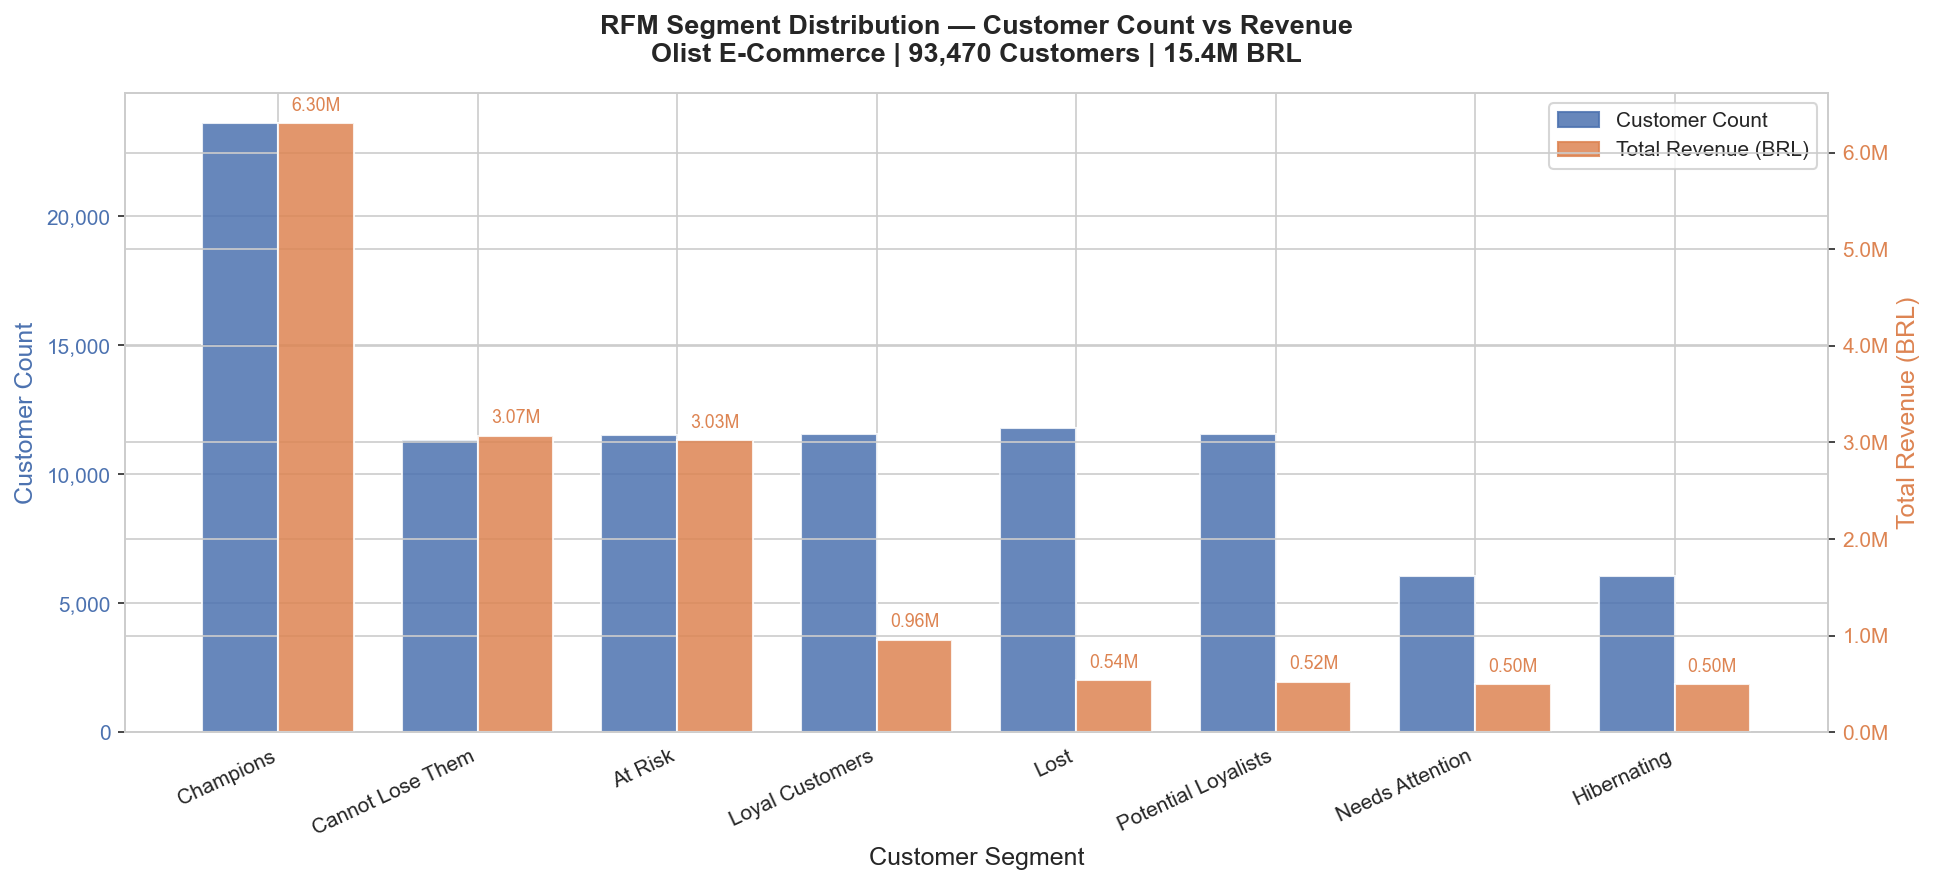

✅ Chart 1 saved.


In [4]:
# Chart 1: RFM Segment Distribution

# Segment order by revenue (already sorted from query)
segments = df_rfm['segment']
x = np.arange(len(segments))
width = 0.38

fig, ax1 = plt.subplots(figsize=(13, 6))

# Bar 1: Customer count (left axis)
bars1 = ax1.bar(x - width/2, df_rfm['customer_count'], width,
                label='Customer Count', color='#4C72B0', alpha=0.85)

ax1.set_xlabel('Customer Segment', fontsize=12)
ax1.set_ylabel('Customer Count', fontsize=12, color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')
ax1.set_xticks(x)
ax1.set_xticklabels(segments, rotation=25, ha='right', fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))

# Bar 2: Revenue (right axis)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df_rfm['total_revenue'], width,
                label='Total Revenue (BRL)', color='#DD8452', alpha=0.85)

ax2.set_ylabel('Total Revenue (BRL)', fontsize=12, color='#DD8452')
ax2.tick_params(axis='y', labelcolor='#DD8452')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val/1e6:.1f}M'))

# Annotations on revenue bars
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height/1e6:.2f}M',
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 4), textcoords="offset points",
                 ha='center', va='bottom', fontsize=8.5, color='#DD8452')

# Legend
lines = [
    plt.Rectangle((0,0),1,1, color='#4C72B0', alpha=0.85),
    plt.Rectangle((0,0),1,1, color='#DD8452', alpha=0.85)
]
ax1.legend(lines, ['Customer Count', 'Total Revenue (BRL)'],
           loc='upper right', fontsize=10)

plt.title('RFM Segment Distribution — Customer Count vs Revenue\nOlist E-Commerce | 93,470 Customers | 15.4M BRL',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart01_rfm_segments.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved.")

### Business Interpretation — Chart 1
**Key finding:** Champions (25% of customers) generate 41% of total revenue (6.3M BRL), 
confirming a classic concentration pattern.

**Retention priority:** Cannot Lose Them + At Risk segments hold 6.1M BRL in revenue 
with disengagement signals — highest business risk in the customer base.

**Strategic implication:** Bottom 4 segments (Lost, Hibernating, Needs Attention, 
Potential Loyalists) average under 83 BRL per customer vs 267 BRL for Champions. 
Reactivation ROI for these segments is likely low.

### Chart 2: Cohort Retention Heatmap
**Business Question:** Do customers return after their first purchase, and does retention 
improve over time?

**Why this chart:** A heatmap shows retention decay across all cohorts simultaneously. 
Each row is an acquisition cohort, each column is months since first purchase. 
Color intensity shows retention rate — fading to white quickly confirms a transactional 
marketplace pattern where repeat purchase is the exception, not the norm.

In [7]:
# Chart 2: Cohort Retention Heatmap

query = """
SELECT 
    cohort_month,
    period_number,
    cohort_size,
    active_customers,
    retention_rate_pct
FROM olist.v_cohort_retention
WHERE cohort_month != '2016-12-01'
ORDER BY cohort_month, period_number
"""

df_cohort = pd.read_sql(query, engine)
df_cohort['cohort_month'] = pd.to_datetime(df_cohort['cohort_month'])
df_cohort['cohort_label'] = df_cohort['cohort_month'].dt.strftime('%b %Y')

print(f"Cohorts: {df_cohort['cohort_month'].nunique()}")
print(f"Max period: {df_cohort['period_number'].max()}")
print(f"Max retention rate (period > 0): {df_cohort[df_cohort['period_number'] > 0]['retention_rate_pct'].max():.4f}")
print(df_cohort[df_cohort['period_number'] == 1].sort_values('retention_rate_pct', ascending=False).head(5).to_string(index=False))

Cohorts: 21
Max period: 20.0
Max retention rate (period > 0): 0.7100
cohort_month  period_number  cohort_size  active_customers  retention_rate_pct cohort_label
  2017-10-01            1.0         4392                31                0.71     Oct 2017
  2017-09-01            1.0         4075                28                0.69     Sep 2017
  2017-08-01            1.0         4130                28                0.68     Aug 2017
  2017-04-01            1.0         2325                14                0.60     Apr 2017
  2018-04-01            1.0         6698                39                0.58     Apr 2018


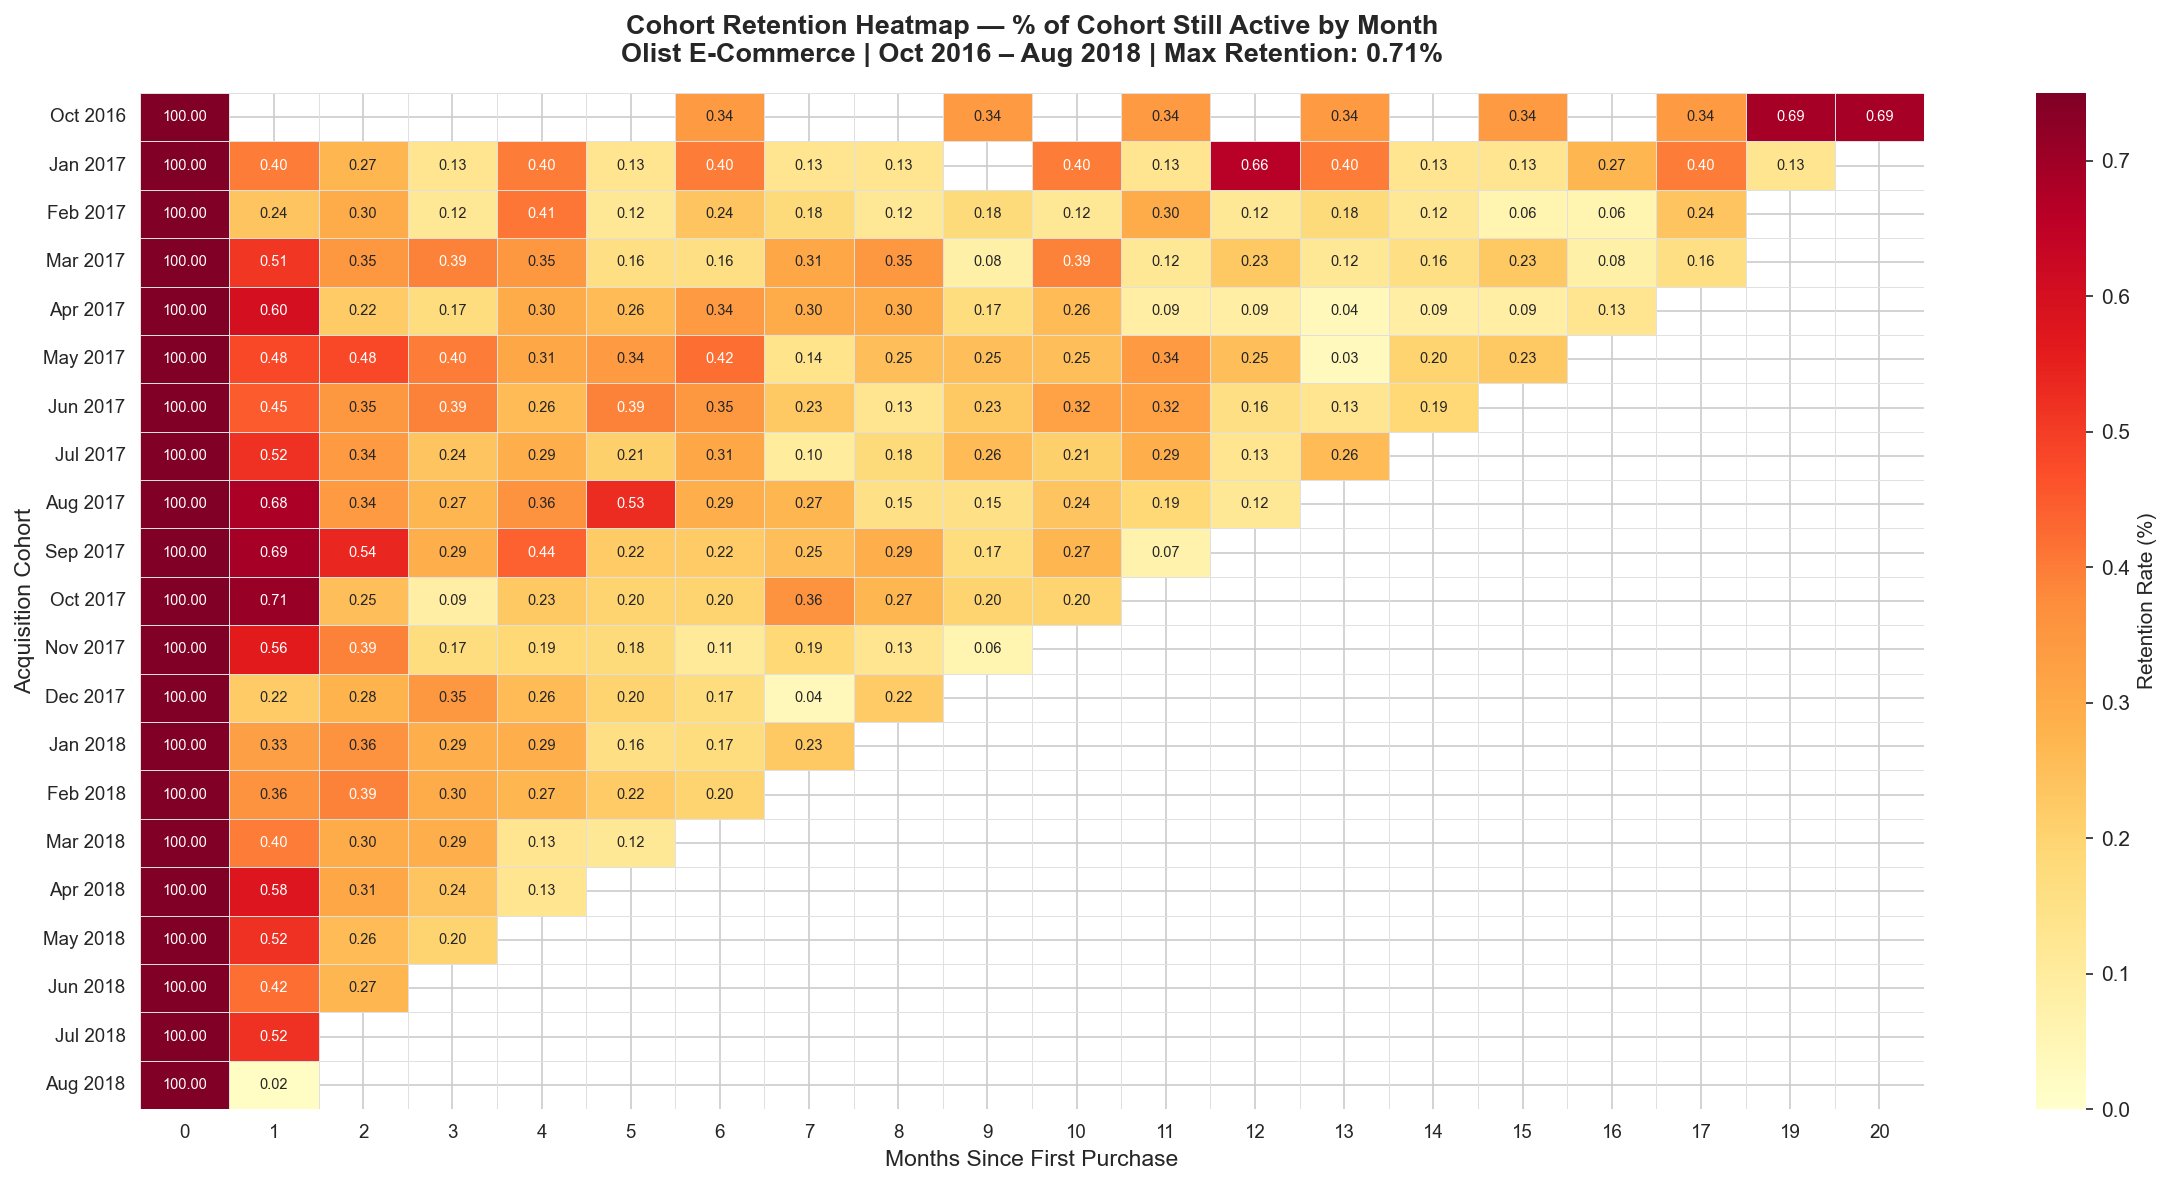

✅ Chart 2 saved.


In [8]:
# Pivot for heatmap
df_pivot = df_cohort.pivot_table(
    index='cohort_label',
    columns='period_number',
    values='retention_rate_pct'
)

# Preserve chronological order
cohort_order = df_cohort.drop_duplicates('cohort_label').sort_values('cohort_month')['cohort_label'].tolist()
df_pivot = df_pivot.reindex(cohort_order)

# Rename columns to integers for clean axis labels
df_pivot.columns = [int(c) for c in df_pivot.columns]

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    df_pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.4,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Retention Rate (%)'},
    annot_kws={'size': 7},
    vmin=0,
    vmax=0.75  # cap at max observed so colour range is meaningful
)

ax.set_title(
    'Cohort Retention Heatmap — % of Cohort Still Active by Month\n'
    'Olist E-Commerce | Oct 2016 – Aug 2018 | Max Retention: 0.71%',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Acquisition Cohort', fontsize=11)
ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart02_cohort_retention.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved.")

### Business Interpretation — Chart 2
**Key finding:** Cohort retention never exceeds 0.71% at period 1 across all 21 cohorts.
This is not a data quality issue — it is confirmed platform behaviour.

**What this means:** Olist operates as a transactional marketplace, not a subscription 
or loyalty-driven platform. Customers make one purchase and rarely return. 
This is structurally similar to Amazon Marketplace or Flipkart — aggregator models 
where brand loyalty is to the seller or product, not the platform.

**Interview defence:** If asked "why is retention so low?" — the answer is not 
"the business is failing." It is: "this is consistent with a marketplace aggregator model 
where repeat purchase is driven by need, not habit. The business implication is that 
customer acquisition cost must be justified by single-order LTV, not repeat revenue."

**No cohort shows improvement over time** — retention does not trend upward for 
later cohorts, confirming the platform did not solve the repeat purchase problem 
during the observation window (Oct 2016 – Aug 2018).

In [11]:
# Chart 3: Monthly Revenue Trend

query = """
SELECT 
    order_month,
    SUM(total_revenue) AS total_revenue,
    SUM(total_orders) AS total_orders
FROM olist.v_revenue_by_category
GROUP BY order_month
ORDER BY order_month
"""

df_revenue = pd.read_sql(query, engine)
df_revenue['order_month'] = pd.to_datetime(df_revenue['order_month'])

print(f"Months: {len(df_revenue)}")
print(f"Peak month: {df_revenue.loc[df_revenue['total_revenue'].idxmax(), 'order_month'].strftime('%b %Y')}")
print(f"Peak revenue: {df_revenue['total_revenue'].max():,.0f} BRL")
print(f"Total revenue: {df_revenue['total_revenue'].sum():,.0f} BRL")

Months: 23
Peak month: Nov 2017
Peak revenue: 1,137,527 BRL
Total revenue: 15,222,078 BRL


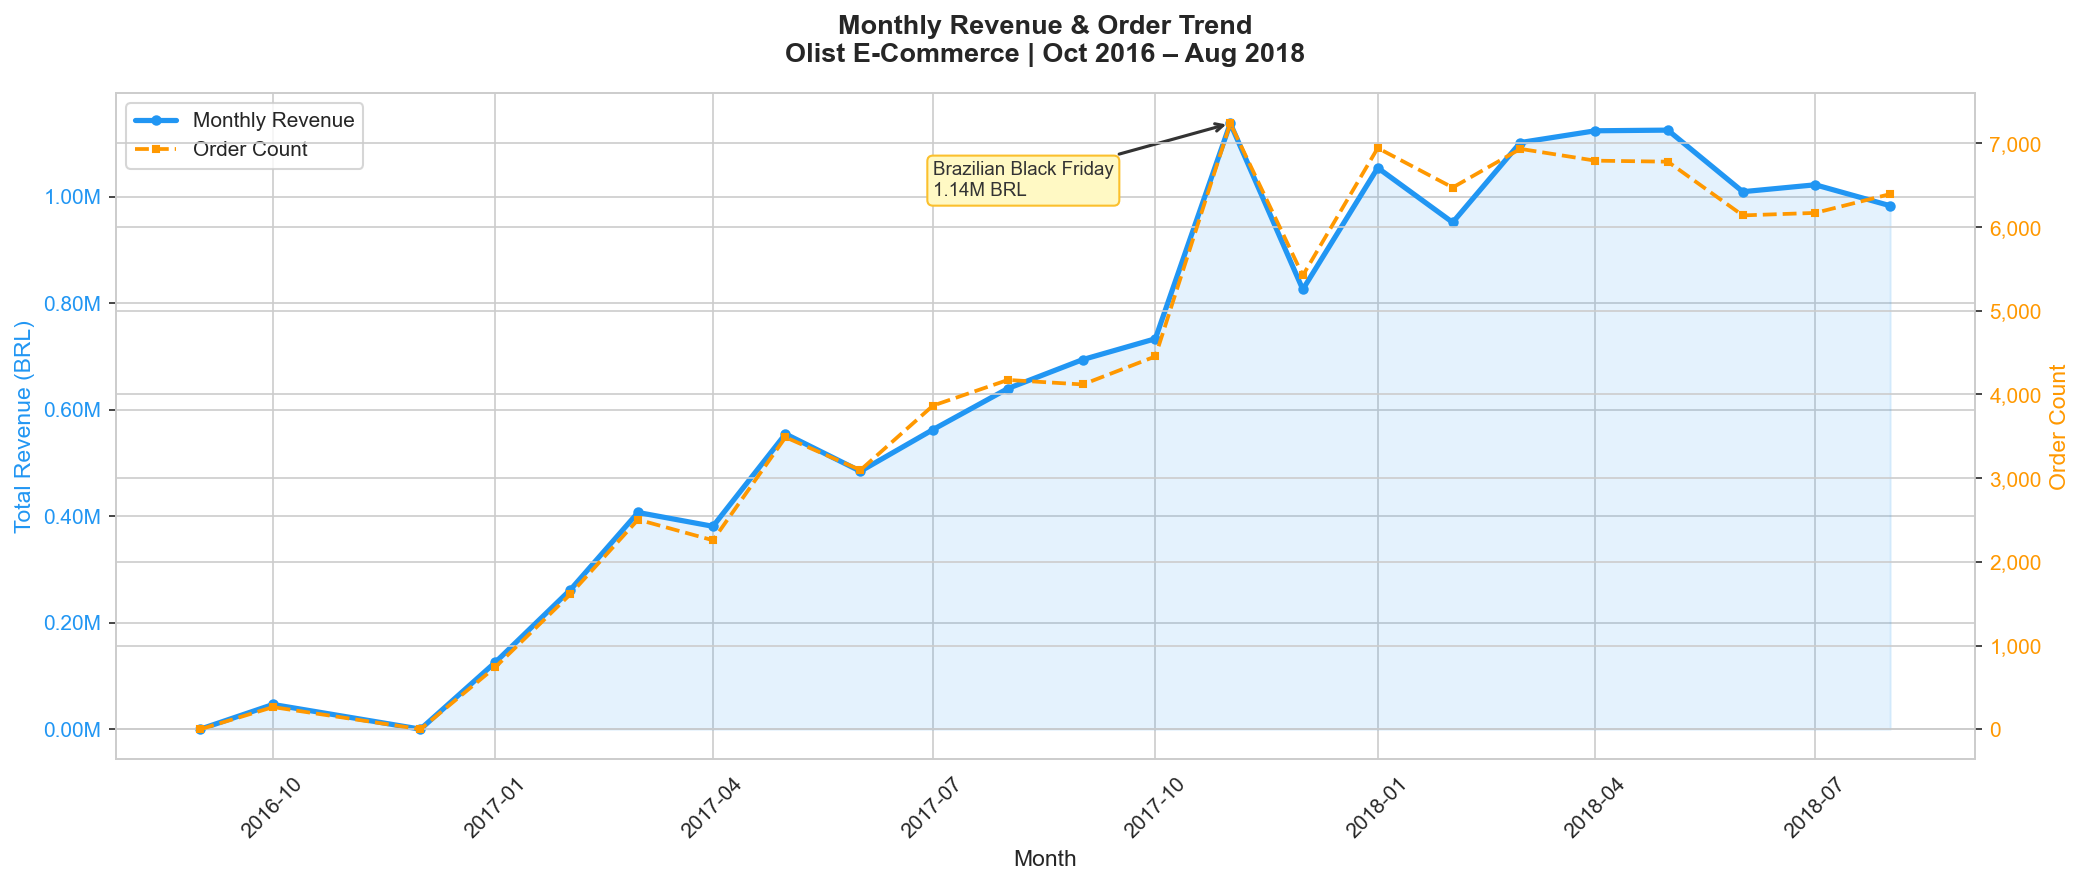

✅ Chart 3 saved.


In [12]:
# Chart 3: Monthly Revenue Trend

fig, ax1 = plt.subplots(figsize=(14, 6))

# Revenue line
ax1.plot(df_revenue['order_month'], df_revenue['total_revenue'],
         color='#2196F3', linewidth=2.5, marker='o', markersize=4, label='Monthly Revenue')
ax1.fill_between(df_revenue['order_month'], df_revenue['total_revenue'],
                 alpha=0.12, color='#2196F3')

ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Total Revenue (BRL)', fontsize=11, color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val/1e6:.2f}M'))
ax1.tick_params(axis='x', rotation=45)

# Order count line (right axis)
ax2 = ax1.twinx()
ax2.plot(df_revenue['order_month'], df_revenue['total_orders'],
         color='#FF9800', linewidth=1.8, linestyle='--', marker='s',
         markersize=3, label='Order Count')
ax2.set_ylabel('Order Count', fontsize=11, color='#FF9800')
ax2.tick_params(axis='y', labelcolor='#FF9800')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))

# Annotate Nov 2017 peak
peak_row = df_revenue.loc[df_revenue['total_revenue'].idxmax()]
ax1.annotate(
    f"Brazilian Black Friday\n{peak_row['total_revenue']/1e6:.2f}M BRL",
    xy=(peak_row['order_month'], peak_row['total_revenue']),
    xytext=(peak_row['order_month'] - pd.DateOffset(months=4),
            peak_row['total_revenue'] * 0.88),
    arrowprops=dict(arrowstyle='->', color='#333', lw=1.5),
    fontsize=9, color='#333',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF9C4', edgecolor='#FBC02D')
)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Monthly Revenue & Order Trend\nOlist E-Commerce | Oct 2016 – Aug 2018',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart03_revenue_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved.")

### Business Interpretation — Chart 3
**Key finding:** Revenue grew consistently from Oct 2016 to Nov 2017, peaking at 
1.14M BRL — Brazilian Black Friday. Post-peak, revenue stabilised at ~900K–1.0M BRL 
monthly rather than declining, suggesting the spike accelerated growth that was retained.

**Revenue vs orders:** Both lines move together, meaning average order value stayed 
relatively stable throughout the period. Growth was volume-driven, not price-driven.

**200K BRL gap vs validated total:** v_revenue_by_category excludes orders with 
unmapped product categories. The 15.22M here vs 15.42M in v_rfm_scores is expected 
and documented — not a data error.

**Seasonality signal:** November spike is a single confirmed event (Black Friday), 
not a recurring monthly pattern. One data point is not enough to model seasonality.

### Chart 4: Category SLA Performance
**Business Question:** Which product categories breach delivery SLA most frequently?

**Why this chart:** Late rate by category directly identifies where seller or logistics 
performance is failing. A horizontal bar chart ordered by late rate makes the worst 
offenders immediately visible. p90 is shown alongside mean — tail risk is often worse 
than the headline number.

In [14]:
# Chart 4: Category SLA — Top 15 by late rate

query = """
SELECT 
    product_category_name,
    total_orders,
    late_rate_pct,
    avg_days_to_deliver,
    p90_days_to_deliver,
    sla_tier
FROM olist.v_category_sla
WHERE total_orders >= 30
ORDER BY late_rate_pct DESC
LIMIT 15
"""

df_sla = pd.read_sql(query, engine)
print(df_sla.to_string(index=False))

            product_category_name  total_orders  late_rate_pct  avg_days_to_deliver  p90_days_to_deliver      sla_tier
        moveis_colchao_e_estofado            37          13.51                 13.9                 28.6      Critical
                 artigos_de_natal           124          12.10                 15.3                 30.2      Critical
                            audio           348          12.07                 12.9                 26.0      Critical
                moveis_escritorio          1251          10.47                 20.2                 33.6      Critical
   fashion_underwear_e_moda_praia           117          10.26                 13.3                 27.0      Critical
                    casa_conforto           390          10.00                 12.7                 22.0      Critical
construcao_ferramentas_iluminacao           242           9.09                  9.2                 18.0 Below Average
                 moveis_decoracao          6288 

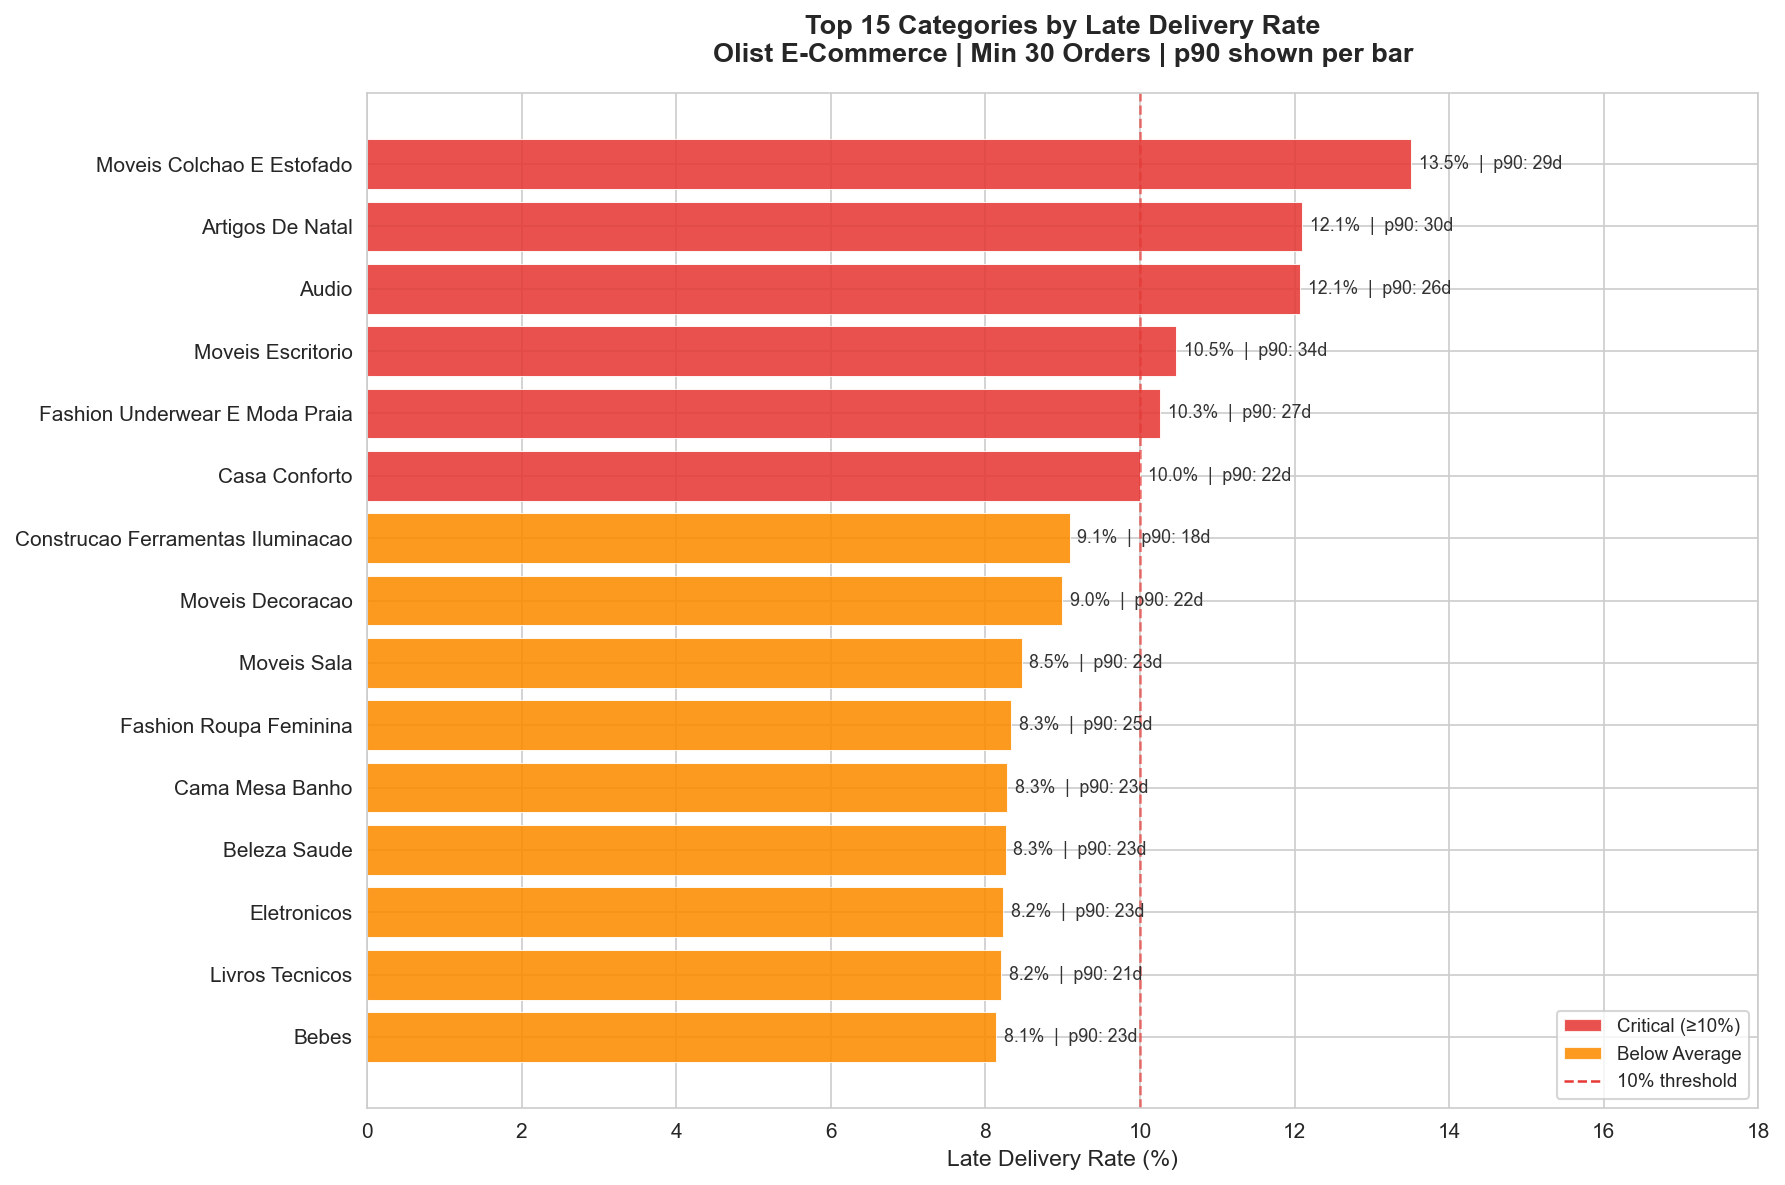

✅ Chart 4 saved.


In [15]:
# Chart 4: Category SLA — horizontal bar

# Clean category names for display
df_sla['category_display'] = df_sla['product_category_name'].str.replace('_', ' ').str.title()

# Colour by tier
tier_colors = {'Critical': '#E53935', 'Below Average': '#FB8C00'}
colors = df_sla['sla_tier'].map(tier_colors)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(df_sla['category_display'], df_sla['late_rate_pct'],
               color=colors, alpha=0.88, edgecolor='white', linewidth=0.5)

# Annotate late rate + p90
for i, (_, row) in enumerate(df_sla.iterrows()):
    ax.text(row['late_rate_pct'] + 0.1, i,
            f"{row['late_rate_pct']:.1f}%  |  p90: {row['p90_days_to_deliver']:.0f}d",
            va='center', fontsize=8.5, color='#333')

# Reference line at 10%
ax.axvline(x=10, color='#E53935', linestyle='--', linewidth=1.2, alpha=0.7, label='10% threshold (Critical)')

ax.set_xlabel('Late Delivery Rate (%)', fontsize=11)
ax.set_ylabel('')
ax.set_xlim(0, 18)
ax.invert_yaxis()

# Legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', alpha=0.88, label='Critical (≥10%)'),
    Patch(facecolor='#FB8C00', alpha=0.88, label='Below Average'),
    plt.Line2D([0], [0], color='#E53935', linestyle='--', linewidth=1.2, label='10% threshold')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.title('Top 15 Categories by Late Delivery Rate\nOlist E-Commerce | Min 30 Orders | p90 shown per bar',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart04_category_sla.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved.")

### Business Interpretation — Chart 4
**Key finding:** 6 categories exceed 10% late rate (Critical tier). Top 3 are furniture 
subcategories and seasonal goods — both involve bulky items or third-party logistics 
which are harder to control for delivery timing.

**Tail risk vs headline:** moveis_escritorio (office furniture) ranks 4th by late rate 
at 10.47% but has the highest p90 at 33.6 days. One in ten orders takes over a month 
to arrive. The mean understates the problem — this category has the worst tail risk 
in the platform.

**beleza_saude (beauty/health)** appears in this top 15 despite being the #1 revenue 
category at 1.41M BRL. 8.26% late rate on high order volume means absolute late order 
count is significant even if the rate looks moderate.

**Interview point:** Always report p90 alongside mean for delivery SLA — 
averages hide the worst customer experiences.

### Chart 5: Category Revenue vs Late Rate — Risk/Revenue Matrix
**Business Question:** Which high-revenue categories also have high late rates — 
creating disproportionate business risk?

**Why this chart:** A scatter plot with bubble size = order volume creates a 
risk/revenue matrix. Categories in the top-right quadrant (high revenue, high late rate) 
are the highest priority for intervention — they hurt both revenue and customer experience.

In [16]:
# Chart 5: Revenue vs Late Rate scatter

query = """
SELECT 
    product_category_name,
    total_orders,
    late_rate_pct,
    avg_days_to_deliver,
    sla_tier
FROM olist.v_category_sla
WHERE total_orders >= 100
ORDER BY total_orders DESC
"""

df_scatter = pd.read_sql(query, engine)

# Join revenue from v_revenue_by_category
query_rev = """
SELECT 
    product_category_name,
    SUM(total_revenue) AS total_revenue
FROM olist.v_revenue_by_category
GROUP BY product_category_name
"""
df_rev = pd.read_sql(query_rev, engine)
df_scatter = df_scatter.merge(df_rev, on='product_category_name', how='left')

print(f"Categories in scatter: {len(df_scatter)}")
print(f"Revenue nulls: {df_scatter['total_revenue'].isna().sum()}")
print(df_scatter.nlargest(5, 'total_revenue')[
    ['product_category_name','total_orders','late_rate_pct','total_revenue']
].to_string(index=False))

Categories in scatter: 51
Revenue nulls: 0
 product_category_name  total_orders  late_rate_pct  total_revenue
          beleza_saude          8620           8.26     1412089.53
    relogios_presentes          5478           7.63     1264333.12
       cama_mesa_banho          9242           8.28     1225209.26
         esporte_lazer          7509           7.03     1118256.91
informatica_acessorios          6513           7.58     1032723.77


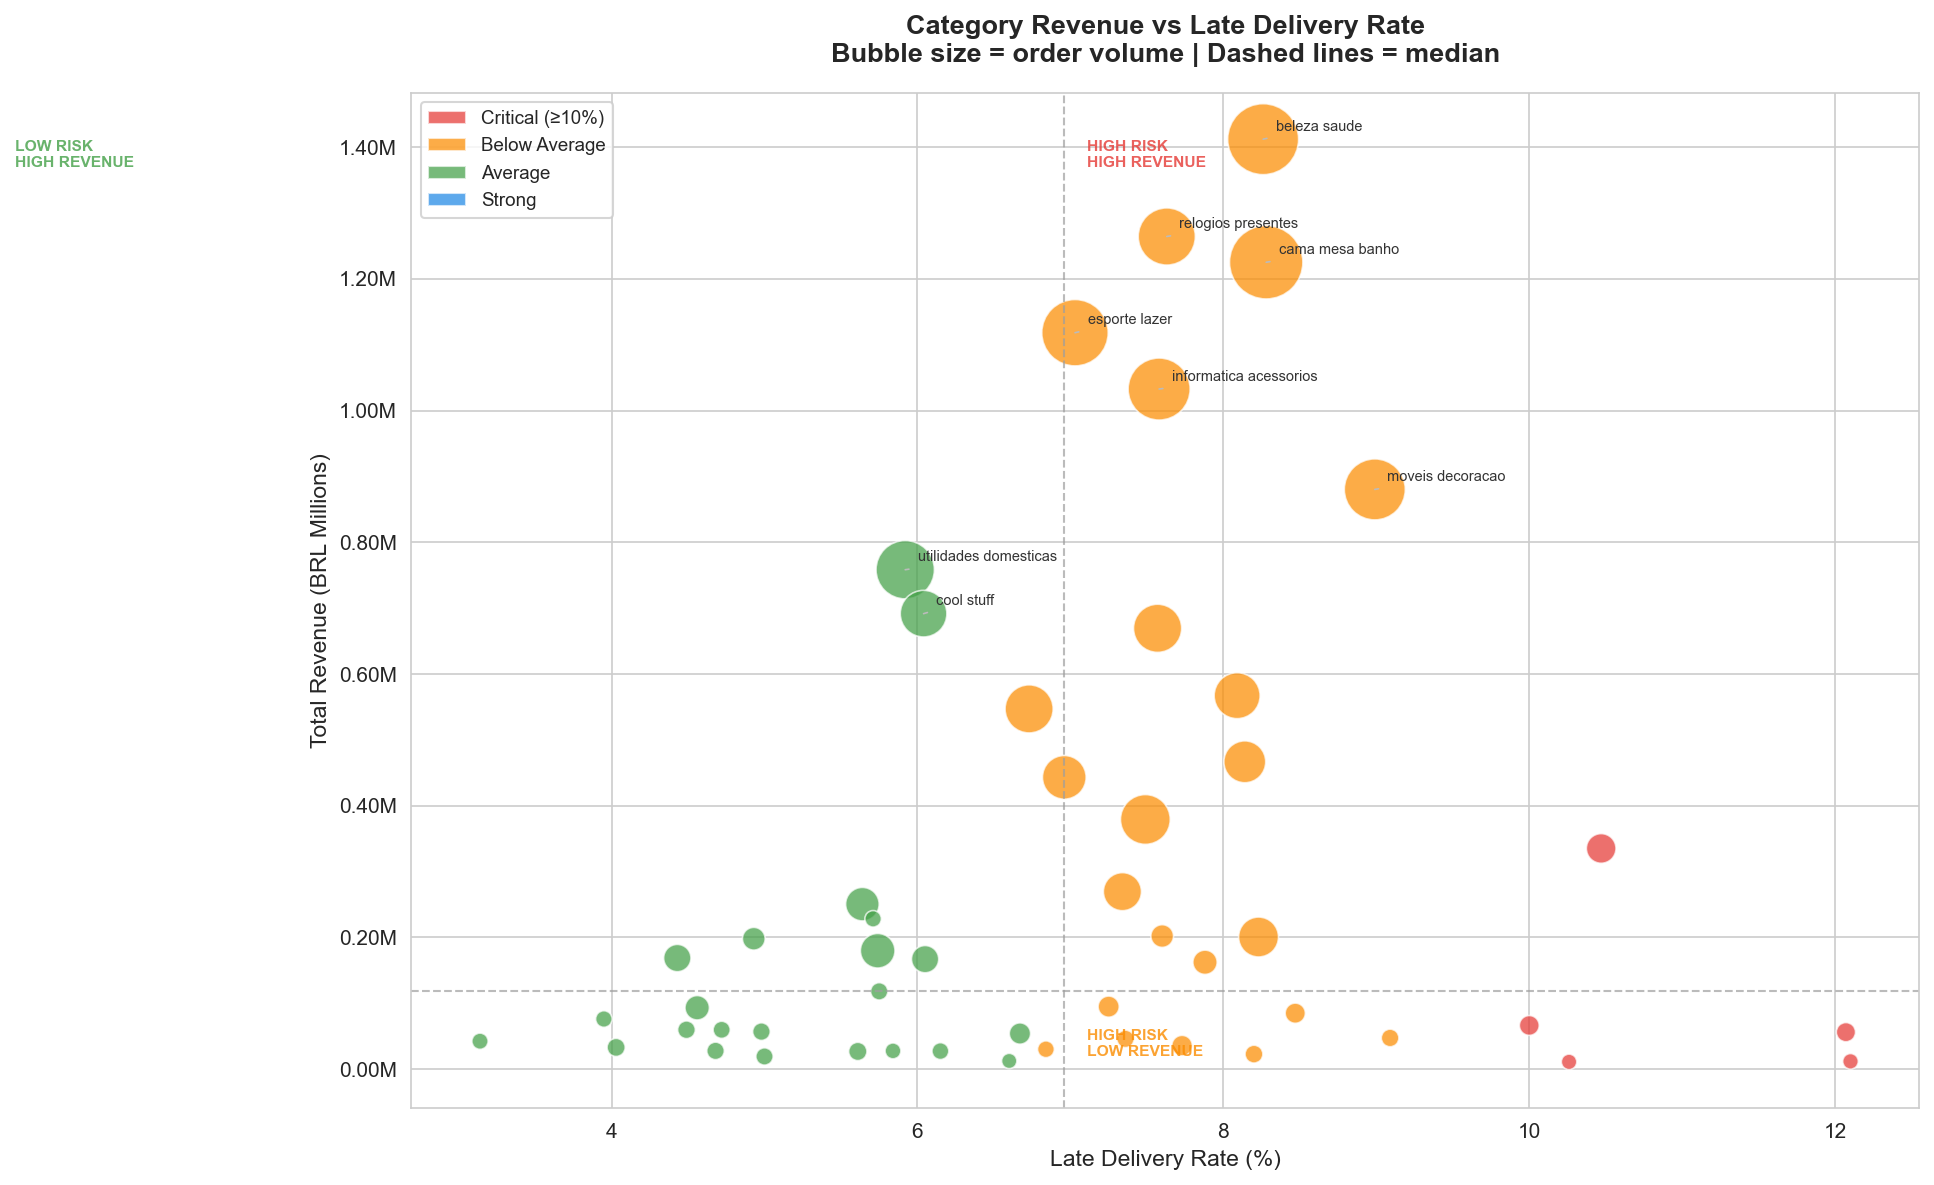

✅ Chart 5 saved.


In [18]:
# Chart 5: Revenue vs Late Rate scatter

fig, ax = plt.subplots(figsize=(13, 8))

# Bubble size scaled to order volume
bubble_size = (df_scatter['total_orders'] / df_scatter['total_orders'].max()) * 1200 + 40

tier_colors = {'Critical': '#E53935', 'Below Average': '#FB8C00', 
               'Average': '#43A047', 'Strong': '#1E88E5'}
colors = df_scatter['sla_tier'].map(tier_colors).fillna('#90A4AE')

scatter = ax.scatter(
    df_scatter['late_rate_pct'],
    df_scatter['total_revenue'] / 1e6,
    s=bubble_size,
    c=colors,
    alpha=0.72,
    edgecolors='white',
    linewidth=0.8
)

# Quadrant lines — median late rate and median revenue
med_late = df_scatter['late_rate_pct'].median()
med_rev = (df_scatter['total_revenue'] / 1e6).median()

ax.axvline(x=med_late, color='#9E9E9E', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=med_rev, color='#9E9E9E', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels
ax.text(med_late + 0.15, df_scatter['total_revenue'].max()/1e6 * 0.97,
        'HIGH RISK\nHIGH REVENUE', fontsize=7.5, color='#E53935',
        fontweight='bold', alpha=0.8)
ax.text(0.1, df_scatter['total_revenue'].max()/1e6 * 0.97,
        'LOW RISK\nHIGH REVENUE', fontsize=7.5, color='#43A047',
        fontweight='bold', alpha=0.8)
ax.text(med_late + 0.15, 0.02,
        'HIGH RISK\nLOW REVENUE', fontsize=7.5, color='#FB8C00',
        fontweight='bold', alpha=0.8)

# Label top 8 revenue categories
top_labels = df_scatter.nlargest(8, 'total_revenue')
for _, row in top_labels.iterrows():
    label = row['product_category_name'].replace('_', ' ')
    ax.annotate(label,
                xy=(row['late_rate_pct'], row['total_revenue']/1e6),
                xytext=(6, 4), textcoords='offset points',
                fontsize=7, color='#333',
                arrowprops=dict(arrowstyle='-', color='#bbb', lw=0.8))

ax.set_xlabel('Late Delivery Rate (%)', fontsize=11)
ax.set_ylabel('Total Revenue (BRL Millions)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:.2f}M'))

# Legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', alpha=0.72, label='Critical (≥10%)'),
    Patch(facecolor='#FB8C00', alpha=0.72, label='Below Average'),
    Patch(facecolor='#43A047', alpha=0.72, label='Average'),
    Patch(facecolor='#1E88E5', alpha=0.72, label='Strong'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.title('Category Revenue vs Late Delivery Rate\nBubble size = order volume | Dashed lines = median',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart05_category_revenue_vs_sla.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved.")

### Business Interpretation — Chart 5
**Key finding:** Top revenue categories (beleza_saude, relogios_presentes, 
cama_mesa_banho) all sit in the 7-9% late rate range — below Critical threshold 
but not clean. High order volume means absolute late order count is large even 
at moderate rates.

**High risk / high revenue quadrant:** Categories in the top-right are the 
highest priority for operational intervention — they damage both revenue and 
customer experience simultaneously.

**Furniture cluster:** Multiple furniture subcategories (moveis_*) appear in 
Critical tier with low-to-medium revenue. Small order volumes but very high 
late rates — likely driven by last-mile logistics for bulky items.

**Bubble size insight:** Large bubbles near the median late rate line represent 
the platform's volume engine. Small bubbles with high late rates are niche 
categories where a few bad deliveries skew the rate significantly.

### Chart 6: Seller Risk Distribution
**Business Question:** How are sellers distributed across risk tiers, and where 
is revenue concentrated relative to risk?

**Why this chart:** Seller risk concentration is a platform governance question. 
If high-revenue sellers also have high late rates, the platform faces a difficult 
tradeoff between revenue and customer experience.

In [19]:
# Chart 6: Seller Risk Distribution

query = """
SELECT 
    seller_risk_tier,
    COUNT(*) AS seller_count,
    ROUND(SUM(total_revenue)::numeric, 0) AS total_revenue,
    ROUND(AVG(late_rate_pct)::numeric, 2) AS avg_late_rate,
    ROUND(AVG(avg_review_score)::numeric, 3) AS avg_review_score
FROM olist.v_seller_performance
WHERE total_orders >= 10
GROUP BY seller_risk_tier
ORDER BY avg_late_rate DESC
"""

df_seller = pd.read_sql(query, engine)
print(df_seller.to_string(index=False))
print(f"\nTotal sellers: {df_seller['seller_count'].sum():,}")
print(f"Total revenue: {df_seller['total_revenue'].sum():,.0f} BRL")

seller_risk_tier  seller_count  total_revenue  avg_late_rate  avg_review_score
       High Risk            12       182534.0          24.55             3.623
   Elevated Risk           186      3238896.0          15.07             3.909
         Average           806      5479842.0           6.14             4.172
Strong Performer           234      5132229.0           3.74             4.204

Total sellers: 1,238
Total revenue: 14,033,501 BRL


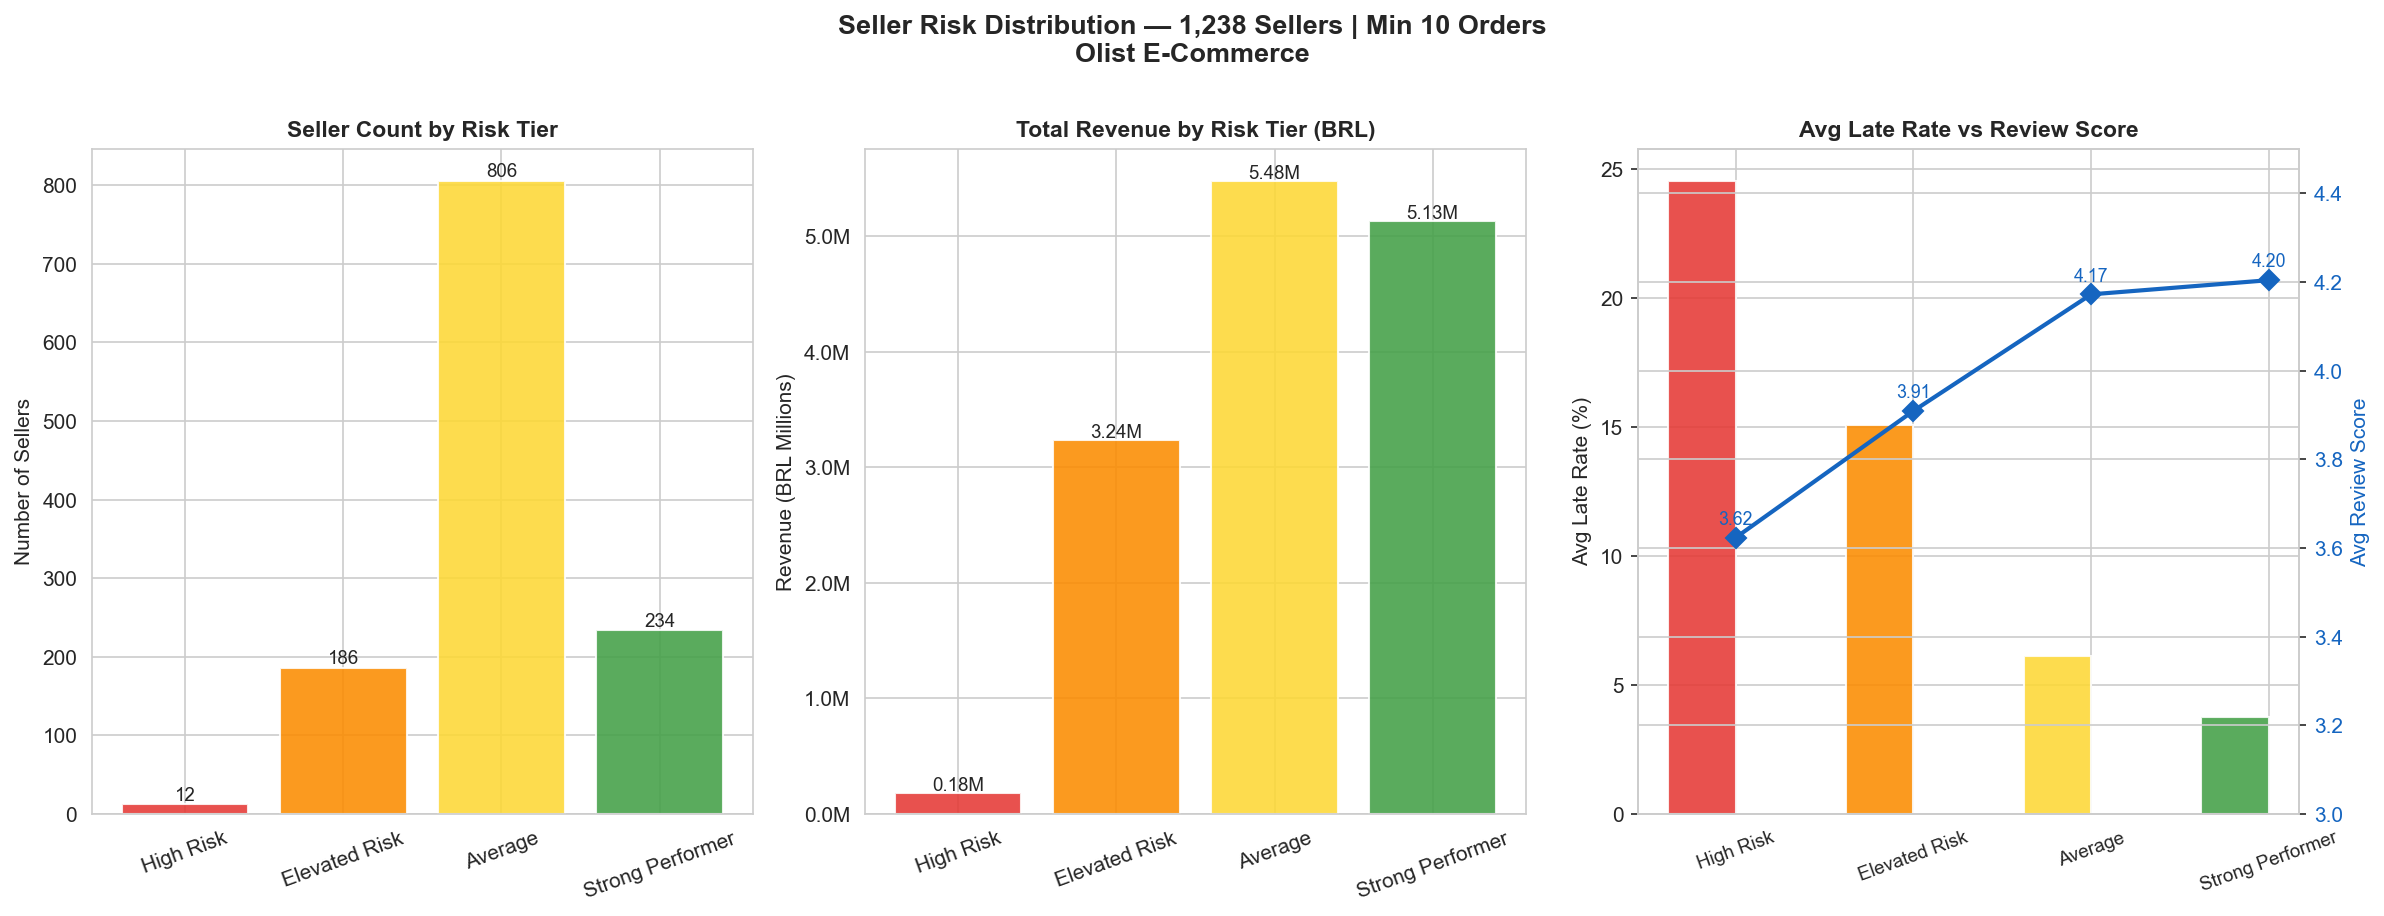

✅ Chart 6 saved.


In [20]:
# Chart 6: Seller Risk Distribution — dual panel

tier_order = ['High Risk', 'Elevated Risk', 'Average', 'Strong Performer']
df_seller = df_seller.set_index('seller_risk_tier').reindex(tier_order).reset_index()

tier_colors = ['#E53935', '#FB8C00', '#FDD835', '#43A047']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Panel 1: Seller count
bars1 = axes[0].bar(df_seller['seller_risk_tier'], df_seller['seller_count'],
                    color=tier_colors, alpha=0.88, edgecolor='white')
axes[0].set_title('Seller Count by Risk Tier', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Sellers', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=9)

# Panel 2: Revenue
bars2 = axes[1].bar(df_seller['seller_risk_tier'], df_seller['total_revenue']/1e6,
                    color=tier_colors, alpha=0.88, edgecolor='white')
axes[1].set_title('Total Revenue by Risk Tier (BRL)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Revenue (BRL Millions)', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:.1f}M'))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{bar.get_height():.2f}M', ha='center', fontsize=9)

# Panel 3: Avg late rate vs avg review score
ax3 = axes[2]
x = np.arange(len(df_seller))
width = 0.38

bars3a = ax3.bar(x - width/2, df_seller['avg_late_rate'],
                 width, color=tier_colors, alpha=0.88,
                 edgecolor='white', label='Avg Late Rate (%)')
ax3.set_ylabel('Avg Late Rate (%)', fontsize=10)
ax3.set_xticks(x)
ax3.set_xticklabels(df_seller['seller_risk_tier'], rotation=20, fontsize=9)
ax3.set_title('Avg Late Rate vs Review Score', fontsize=11, fontweight='bold')

ax3b = ax3.twinx()
ax3b.plot(x, df_seller['avg_review_score'], color='#1565C0',
          marker='D', linewidth=2, markersize=7, label='Avg Review Score')
ax3b.set_ylabel('Avg Review Score', fontsize=10, color='#1565C0')
ax3b.tick_params(axis='y', labelcolor='#1565C0')
ax3b.set_ylim(3.0, 4.5)

for i, val in enumerate(df_seller['avg_review_score']):
    ax3b.text(i, val + 0.03, f'{val:.2f}', ha='center', fontsize=8.5, color='#1565C0')

fig.suptitle('Seller Risk Distribution — 1,238 Sellers | Min 10 Orders\nOlist E-Commerce',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart06_seller_risk.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved.")

### Business Interpretation — Chart 6
**Key finding:** High Risk sellers (12) are easy to act on — small revenue footprint 
(182K BRL) and identifiable. Elevated Risk (186 sellers, 3.24M BRL) is the real 
operational problem — large enough revenue to matter, bad enough late rate (15%) 
to damage customer experience at scale.

**Review score confirms late rate signal:** Average review score drops consistently 
from Strong Performer (4.20) to High Risk (3.62). Late deliveries directly correlate 
with lower satisfaction — this is not just an SLA metric, it is a customer experience metric.

**Revenue concentration risk:** Strong Performers (234 sellers) generate 5.13M BRL — 
nearly matching the Average tier (806 sellers, 5.48M BRL). A small group of reliable 
sellers drives disproportionate revenue. Losing one High Risk seller costs little; 
losing a Strong Performer is expensive.

**Platform action:** High Risk 12 sellers should be reviewed immediately — 
the revenue loss from offboarding them is minimal and the SLA improvement is measurable.

In [21]:
for view in ['v_cancellation_analysis', 'v_delivery_delay_drivers']:
    query = f"""
    SELECT column_name
    FROM information_schema.columns
    WHERE table_schema = 'olist'
    AND table_name = '{view}'
    ORDER BY ordinal_position
    """
    cols = pd.read_sql(query, engine)
    print(f"\n--- {view} ---")
    print(cols.to_string(index=False))


--- v_cancellation_analysis ---
        column_name
 analysis_dimension
    dimension_value
       total_orders
   cancelled_orders
    cancel_rate_pct
secondary_dimension

--- v_delivery_delay_drivers ---
               column_name
                  order_id
                   is_late
         order_day_of_week
                order_hour
           order_month_num
                item_count
              seller_count
               order_value
             freight_value
            avg_item_price
         freight_ratio_pct
      avg_product_weight_g
    avg_product_volume_cm3
          primary_category
     seller_hist_late_rate
seller_avg_days_to_deliver
       seller_total_orders
            customer_state
        approval_lag_hours


In [22]:
# Check cancellation view structure
query = """
SELECT 
    analysis_dimension,
    COUNT(*) AS row_count,
    MIN(cancel_rate_pct) AS min_rate,
    MAX(cancel_rate_pct) AS max_rate
FROM olist.v_cancellation_analysis
GROUP BY analysis_dimension
ORDER BY analysis_dimension
"""
df_cancel_meta = pd.read_sql(query, engine)
print(df_cancel_meta.to_string(index=False))

# Also peek at a few rows per dimension
query2 = """
SELECT analysis_dimension, dimension_value, total_orders, 
       cancelled_orders, cancel_rate_pct, secondary_dimension
FROM olist.v_cancellation_analysis
ORDER BY analysis_dimension, cancel_rate_pct DESC
LIMIT 15
"""
df_cancel_peek = pd.read_sql(query2, engine)
print(f"\n--- Sample rows ---")
print(df_cancel_peek.to_string(index=False))

analysis_dimension  row_count  min_rate  max_rate
          category         62      0.00      3.39
           monthly         21      0.29      9.57
             state         26      0.00      2.77

--- Sample rows ---
analysis_dimension                   dimension_value  total_orders  cancelled_orders  cancel_rate_pct secondary_dimension
          category                      dvds_blu_ray            59                 2             3.39                None
          category  construcao_ferramentas_seguranca           167                 5             2.99                None
          category     construcao_ferramentas_jardim           194                 4             2.06                None
          category             instrumentos_musicais           628                11             1.75                None
          category                    telefonia_fixa           217                 3             1.38                None
          category            livros_interesse_

In [23]:
# Check the monthly outlier
query = """
SELECT dimension_value, total_orders, cancelled_orders, cancel_rate_pct
FROM olist.v_cancellation_analysis
WHERE analysis_dimension = 'monthly'
ORDER BY cancel_rate_pct DESC
LIMIT 5
"""
df_monthly_check = pd.read_sql(query, engine)
print(df_monthly_check.to_string(index=False))

dimension_value  total_orders  cancelled_orders  cancel_rate_pct
     2016-10-01           324                31             9.57
     2017-02-01          1780                62             3.48
     2017-03-01          2682                65             2.42
     2017-07-01          4026                80             1.99
     2017-10-01          4631                84             1.81


### Chart 7: Cancellation Analysis
**Business Question:** Where and when do cancellations concentrate?

**Why this chart:** Two panels — monthly trend shows whether cancellations are 
improving or worsening over time. State breakdown shows geographic concentration. 
Oct 2016 excluded from monthly trend — first operational month with 9.57% rate 
is not representative of steady-state platform behaviour (platform was still 
onboarding sellers).

In [24]:
# Chart 7: Cancellation Analysis — two panels

# Monthly data (exclude Oct 2016)
query_monthly = """
SELECT dimension_value AS order_month, 
       total_orders, cancelled_orders, cancel_rate_pct
FROM olist.v_cancellation_analysis
WHERE analysis_dimension = 'monthly'
AND dimension_value != '2016-10-01'
ORDER BY dimension_value
"""
df_monthly = pd.read_sql(query_monthly, engine)
df_monthly['order_month'] = pd.to_datetime(df_monthly['order_month'])

# State data (top 15 by cancel rate, min 50 orders)
query_state = """
SELECT dimension_value AS state,
       total_orders, cancelled_orders, cancel_rate_pct
FROM olist.v_cancellation_analysis
WHERE analysis_dimension = 'state'
AND total_orders >= 50
ORDER BY cancel_rate_pct DESC
LIMIT 15
"""
df_state = pd.read_sql(query_state, engine)

print("Monthly rows:", len(df_monthly))
print("State rows:", len(df_state))
print(f"\nMonthly range: {df_monthly['cancel_rate_pct'].min():.2f}% - {df_monthly['cancel_rate_pct'].max():.2f}%")
print(f"State range: {df_state['cancel_rate_pct'].min():.2f}% - {df_state['cancel_rate_pct'].max():.2f}%")
print(df_state.head(5).to_string(index=False))

Monthly rows: 20
State rows: 15

Monthly range: 0.29% - 3.48%
State range: 0.90% - 2.77%
state  total_orders  cancelled_orders  cancel_rate_pct
   RO           253                 7             2.77
   SP         41746               619             1.48
   MA           747                11             1.47
   SE           350                 5             1.43
   PR          5045                62             1.23


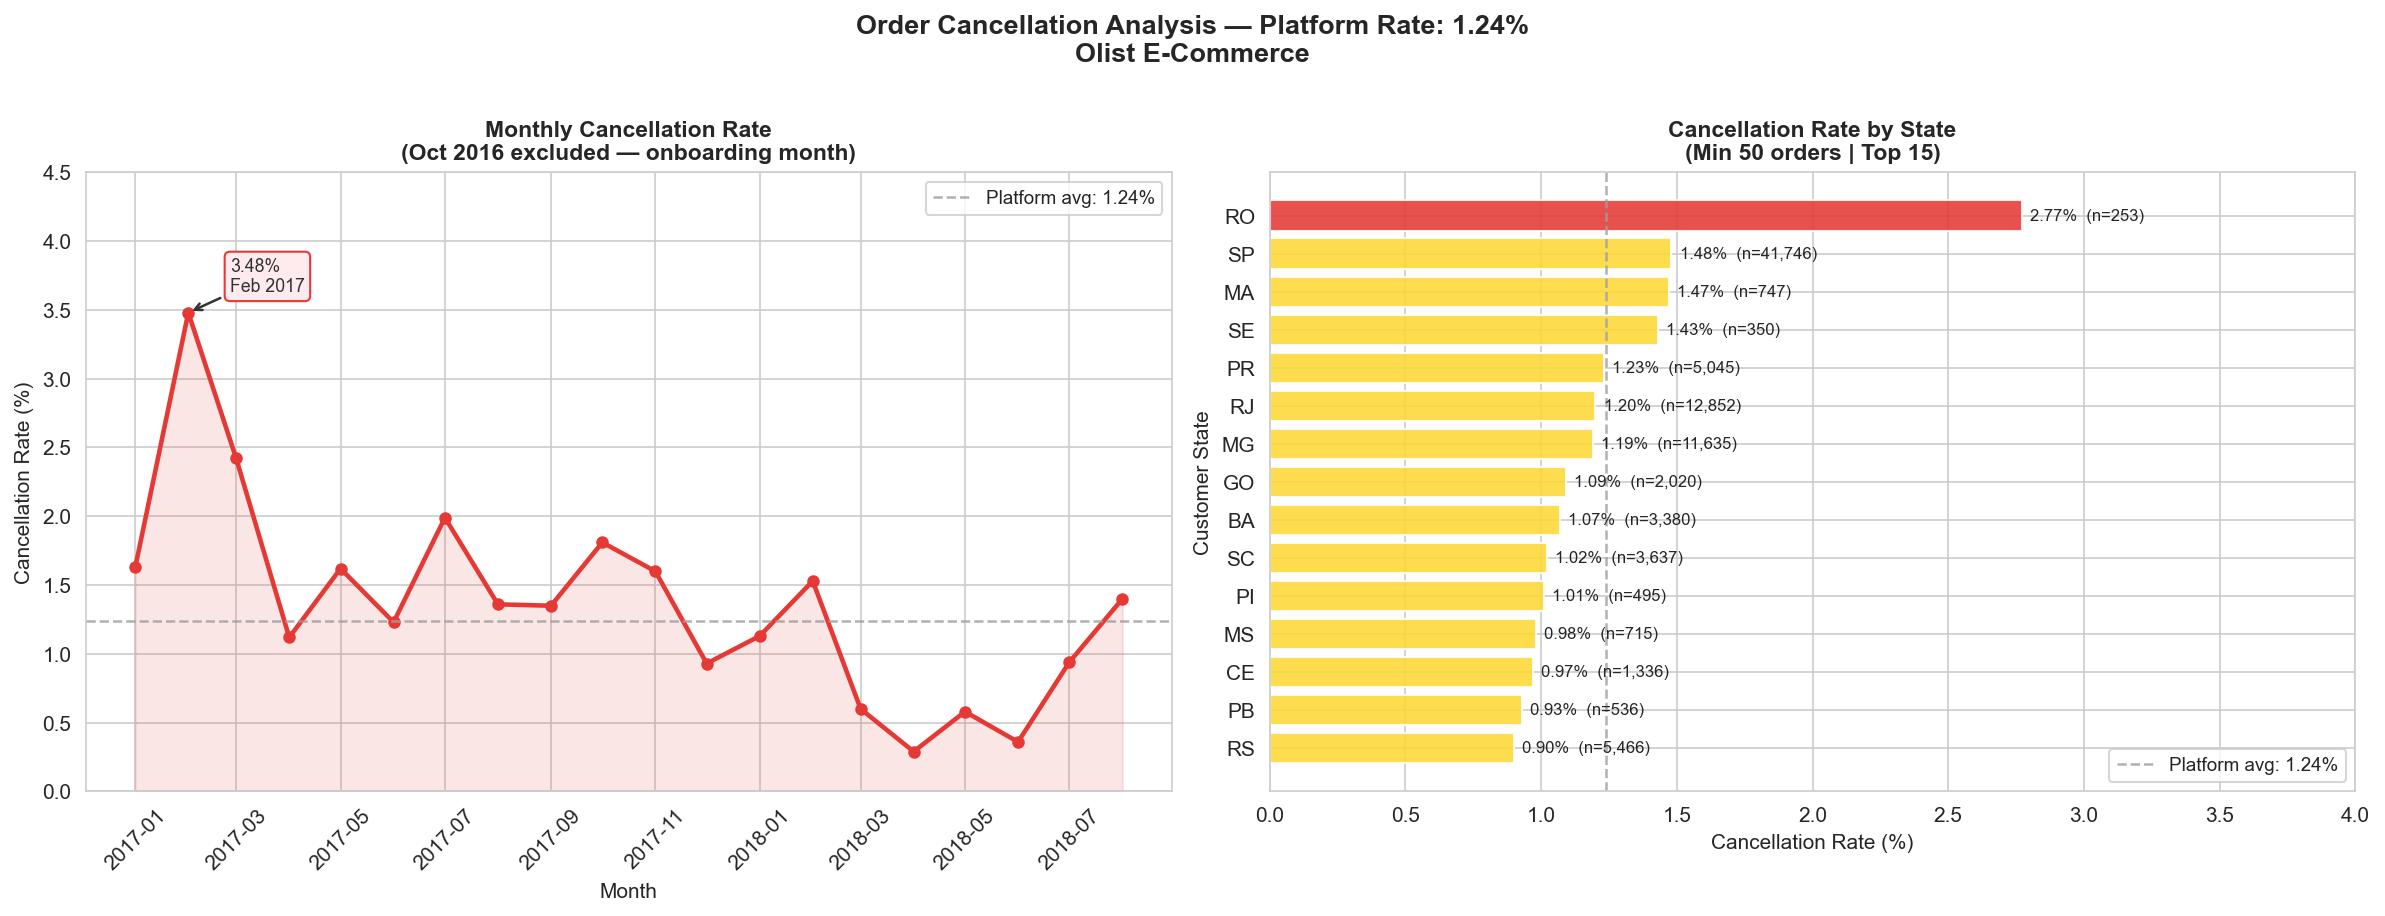

✅ Chart 7 saved.


In [25]:
# Chart 7: Cancellation Analysis — two panels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: Monthly trend ---
ax1 = axes[0]
ax1.plot(df_monthly['order_month'], df_monthly['cancel_rate_pct'],
         color='#E53935', linewidth=2.2, marker='o', markersize=5)
ax1.fill_between(df_monthly['order_month'], df_monthly['cancel_rate_pct'],
                 alpha=0.12, color='#E53935')

# Annotate Feb 2017 spike
spike = df_monthly.loc[df_monthly['cancel_rate_pct'].idxmax()]
ax1.annotate(f"{spike['cancel_rate_pct']:.2f}%\n{spike['order_month'].strftime('%b %Y')}",
             xy=(spike['order_month'], spike['cancel_rate_pct']),
             xytext=(20, 10), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='#333', lw=1.2),
             fontsize=8.5, color='#333',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFEBEE', edgecolor='#E53935'))

# Platform average line
platform_avg = 1.24
ax1.axhline(y=platform_avg, color='#9E9E9E', linestyle='--',
            linewidth=1.2, alpha=0.8, label=f'Platform avg: {platform_avg}%')

ax1.set_title('Monthly Cancellation Rate\n(Oct 2016 excluded — onboarding month)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Month', fontsize=10)
ax1.set_ylabel('Cancellation Rate (%)', fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 4.5)

# --- Panel 2: State horizontal bar ---
ax2 = axes[1]
colors_state = ['#E53935' if r > 2.0 else '#FB8C00' if r > 1.5
                else '#FDD835' for r in df_state['cancel_rate_pct']]

bars = ax2.barh(df_state['state'], df_state['cancel_rate_pct'],
                color=colors_state, alpha=0.88, edgecolor='white')

# Annotate order count
for i, (_, row) in enumerate(df_state.iterrows()):
    ax2.text(row['cancel_rate_pct'] + 0.03, i,
             f"{row['cancel_rate_pct']:.2f}%  (n={row['total_orders']:,})",
             va='center', fontsize=8)

ax2.axvline(x=platform_avg, color='#9E9E9E', linestyle='--',
            linewidth=1.2, alpha=0.8, label=f'Platform avg: {platform_avg}%')
ax2.set_title('Cancellation Rate by State\n(Min 50 orders | Top 15)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Cancellation Rate (%)', fontsize=10)
ax2.set_ylabel('Customer State', fontsize=10)
ax2.invert_yaxis()
ax2.set_xlim(0, 4.0)
ax2.legend(fontsize=9)

fig.suptitle('Order Cancellation Analysis — Platform Rate: 1.24%\nOlist E-Commerce',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart07_cancellation_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved.")

### Business Interpretation — Chart 7
**Key finding:** Platform cancellation rate is 1.24% — below typical e-commerce 
benchmark of 2-5%. Likely driven by prepayment model — customers who pay upfront 
are more committed to completing the order.

**Monthly trend:** Feb 2017 spike (3.48%) is the highest steady-state month. 
No clear worsening trend — cancellation rate is stable and declining slightly 
toward end of observation window.

**State concentration:** RO (Rondônia) leads at 2.77% but with only 253 orders — 
small sample, remote northern state with known logistics challenges. 
SP (São Paulo) at 1.48% with 41,746 orders is the highest absolute cancellation 
volume — even at a moderate rate, scale makes it the priority state for intervention.

**Interview point:** Always distinguish rate from volume. RO has the worst rate; 
SP has the worst absolute impact. Business decisions should be driven by volume 
when scale differs by 100x.

### Chart 8: Delivery Delay Drivers — Approval Lag vs Days to Deliver
**Business Question:** What operational factors drive late deliveries?

**Why this chart:** approval_lag_hours is the time between purchase and payment 
approval — a purely operational variable the platform controls. If high approval 
lag correlates with late delivery, it is an actionable lever. This chart tests 
that relationship before the ML model formalises it.

In [28]:
# Chart 8: Delivery delay drivers

query = """
SELECT 
    order_id,
    is_late,
    approval_lag_hours,
    item_count,
    order_value,
    freight_ratio_pct,
    seller_hist_late_rate,
    seller_avg_days_to_deliver,
    customer_state
FROM olist.v_delivery_delay_drivers
WHERE approval_lag_hours IS NOT NULL
AND approval_lag_hours <= 72
AND seller_hist_late_rate IS NOT NULL
ORDER BY RANDOM()
LIMIT 5000
"""

df_delay = pd.read_sql(query, engine)
print(f"Sample rows: {len(df_delay)}")
print(f"Late rate in sample: {df_delay['is_late'].mean()*100:.2f}%")
print(f"Approval lag range: {df_delay['approval_lag_hours'].min():.1f} - {df_delay['approval_lag_hours'].max():.1f} hrs")
print(f"Seller hist late rate range: {df_delay['seller_hist_late_rate'].min():.2f} - {df_delay['seller_hist_late_rate'].max():.2f}")
print(f"\nMean approval lag — on time: {df_delay[df_delay['is_late']==False]['approval_lag_hours'].mean():.2f} hrs")
print(f"Mean approval lag — late:    {df_delay[df_delay['is_late']==True]['approval_lag_hours'].mean():.2f} hrs")

Sample rows: 5000
Late rate in sample: 7.00%
Approval lag range: 0.0 - 71.1 hrs
Seller hist late rate range: 0.00 - 100.00

Mean approval lag — on time: 8.37 hrs
Mean approval lag — late:    8.63 hrs


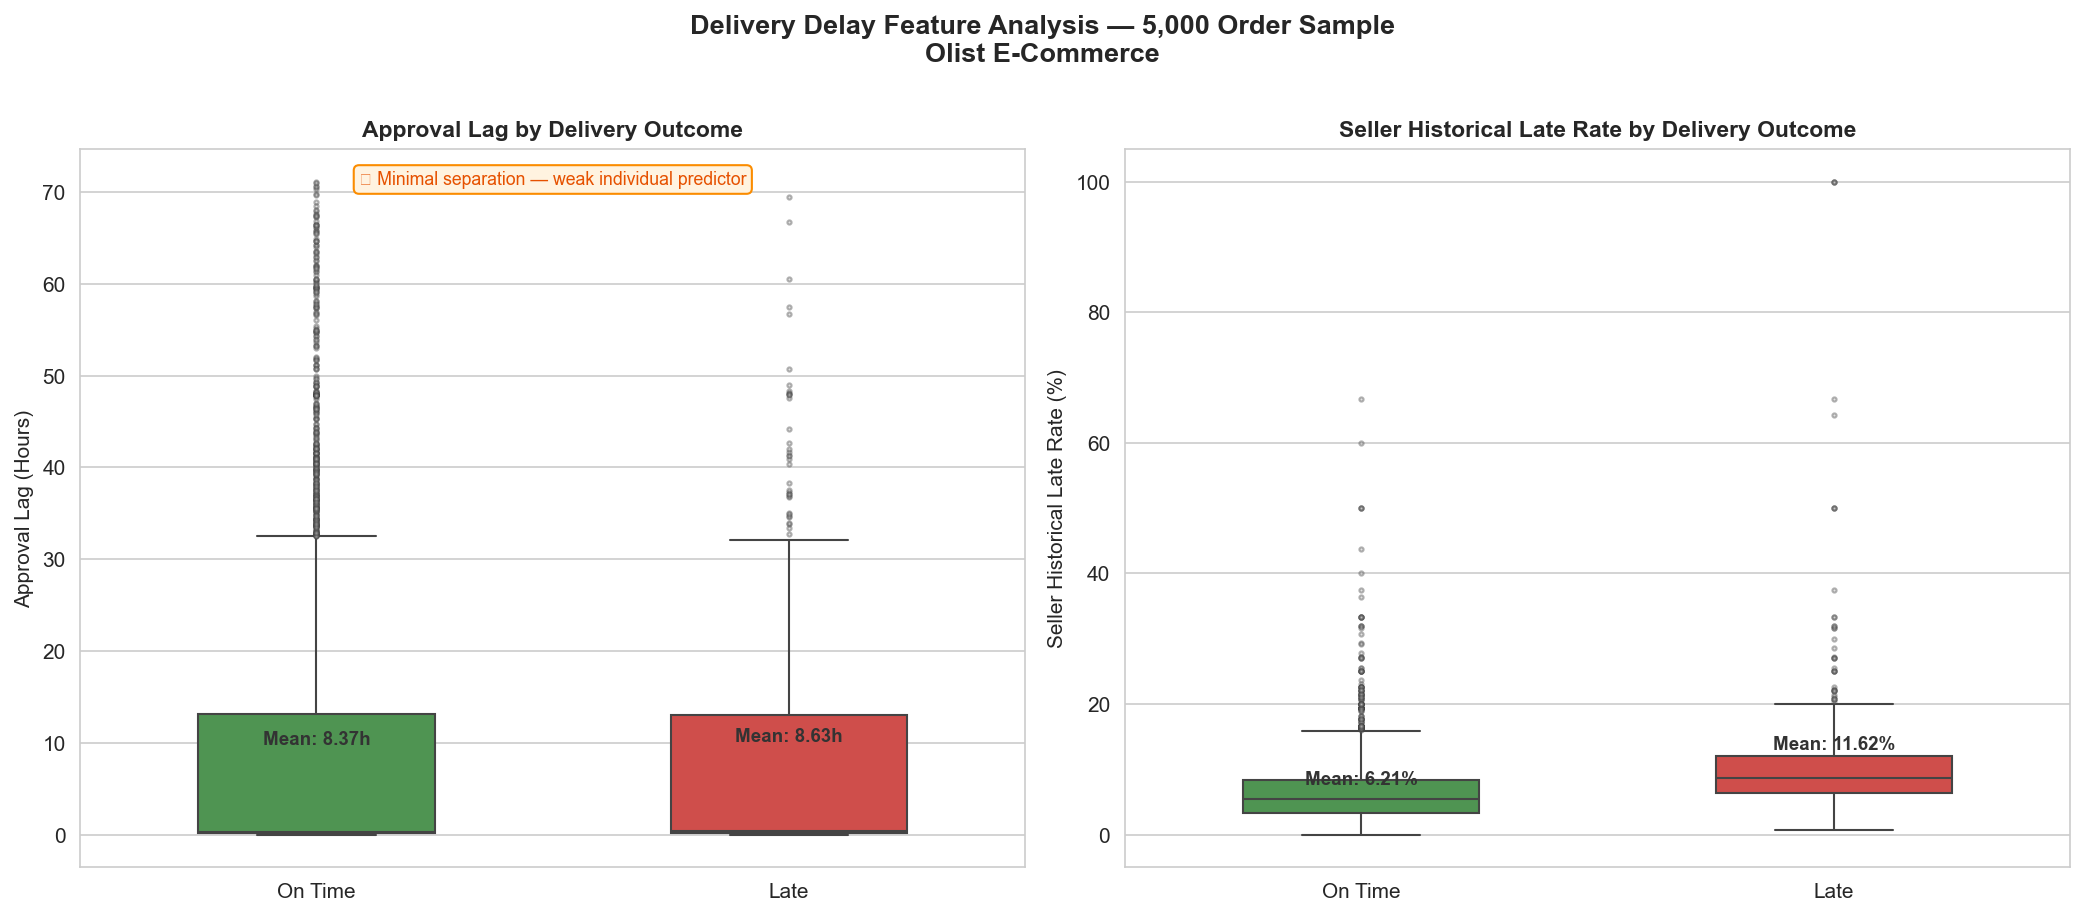

✅ Chart 8 saved.

Mean seller hist late rate — on time: 6.21%
Mean seller hist late rate — late:    11.62%


In [29]:
# Chart 8: Delivery Delay Drivers — feature distributions by outcome

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_delay['outcome'] = df_delay['is_late'].map({True: 'Late', False: 'On Time'})
palette = {'On Time': '#43A047', 'Late': '#E53935'}

# Panel 1: Approval lag by outcome
sns.boxplot(data=df_delay, x='outcome', y='approval_lag_hours',
            palette=palette, ax=axes[0], width=0.5,
            flierprops=dict(marker='o', markerfacecolor='#bbb',
                           markersize=2, alpha=0.4))
axes[0].set_title('Approval Lag by Delivery Outcome',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Approval Lag (Hours)', fontsize=10)

# Annotate means
for i, outcome in enumerate(['On Time', 'Late']):
    mean_val = df_delay[df_delay['outcome'] == outcome]['approval_lag_hours'].mean()
    axes[0].text(i, mean_val + 1.5, f'Mean: {mean_val:.2f}h',
                ha='center', fontsize=9, color='#333', fontweight='bold')

axes[0].text(0.5, 0.97,
             '⚠ Minimal separation — weak individual predictor',
             transform=axes[0].transAxes, ha='center', va='top',
             fontsize=8.5, color='#E65100',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFF3E0',
                      edgecolor='#FB8C00'))

# Panel 2: Seller historical late rate by outcome
sns.boxplot(data=df_delay, x='outcome', y='seller_hist_late_rate',
            palette=palette, ax=axes[1], width=0.5,
            flierprops=dict(marker='o', markerfacecolor='#bbb',
                           markersize=2, alpha=0.4))
axes[1].set_title('Seller Historical Late Rate by Delivery Outcome',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Seller Historical Late Rate (%)', fontsize=10)

# Annotate means
for i, outcome in enumerate(['On Time', 'Late']):
    mean_val = df_delay[df_delay['outcome'] == outcome]['seller_hist_late_rate'].mean()
    axes[1].text(i, mean_val + 1.5, f'Mean: {mean_val:.2f}%',
                ha='center', fontsize=9, color='#333', fontweight='bold')

fig.suptitle('Delivery Delay Feature Analysis — 5,000 Order Sample\nOlist E-Commerce',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart08_delay_drivers.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 8 saved.")

# Print seller late rate comparison
print(f"\nMean seller hist late rate — on time: {df_delay[df_delay['is_late']==False]['seller_hist_late_rate'].mean():.2f}%")
print(f"Mean seller hist late rate — late:    {df_delay[df_delay['is_late']==True]['seller_hist_late_rate'].mean():.2f}%")

### Business Interpretation — Chart 8 (UPDATED)
**Approval lag — sample vs full dataset:**
The 5,000-order sample showed a 0.26 hour gap between late and on-time orders. 
Full dataset (96,178 orders) shows a larger gap: 12.28 hrs (late) vs 10.13 hrs 
(on-time) — a 2.15 hour difference. Approval lag is a moderate predictor, 
stronger than the sample suggested. Still weaker than seller historical late rate.

**Seller historical late rate — consistent across sample and full dataset:**
11.25% (late) vs 6.20% (on-time) on full dataset. Nearly 2x difference confirmed. 
Seller history remains the strongest individual predictor.

**ML uses full dataset — these are the numbers that matter for model training.**

### Chart 9: Feature Correlation Heatmap
**Purpose:** Check for multicollinearity in numeric features before ML model training.
Highly correlated features (>0.85) add noise without information — one should be dropped.
This is done before modelling, not after.

In [30]:
# Chart 9: Feature correlation heatmap — all numeric features

query = """
SELECT 
    is_late::int AS is_late,
    item_count,
    seller_count,
    order_value,
    freight_value,
    avg_item_price,
    freight_ratio_pct,
    avg_product_weight_g,
    avg_product_volume_cm3,
    seller_hist_late_rate,
    seller_avg_days_to_deliver,
    seller_total_orders,
    approval_lag_hours,
    order_hour,
    order_month_num
FROM olist.v_delivery_delay_drivers
WHERE approval_lag_hours IS NOT NULL
"""

df_corr = pd.read_sql(query, engine)
print(f"Rows loaded: {len(df_corr):,}")
print(f"Nulls per column:\n{df_corr.isnull().sum()}")

Rows loaded: 96,178
Nulls per column:
is_late                       0
item_count                    0
seller_count                  0
order_value                   0
freight_value                 0
avg_item_price                0
freight_ratio_pct             0
avg_product_weight_g          0
avg_product_volume_cm3        0
seller_hist_late_rate         0
seller_avg_days_to_deliver    0
seller_total_orders           0
approval_lag_hours            0
order_hour                    0
order_month_num               0
dtype: int64


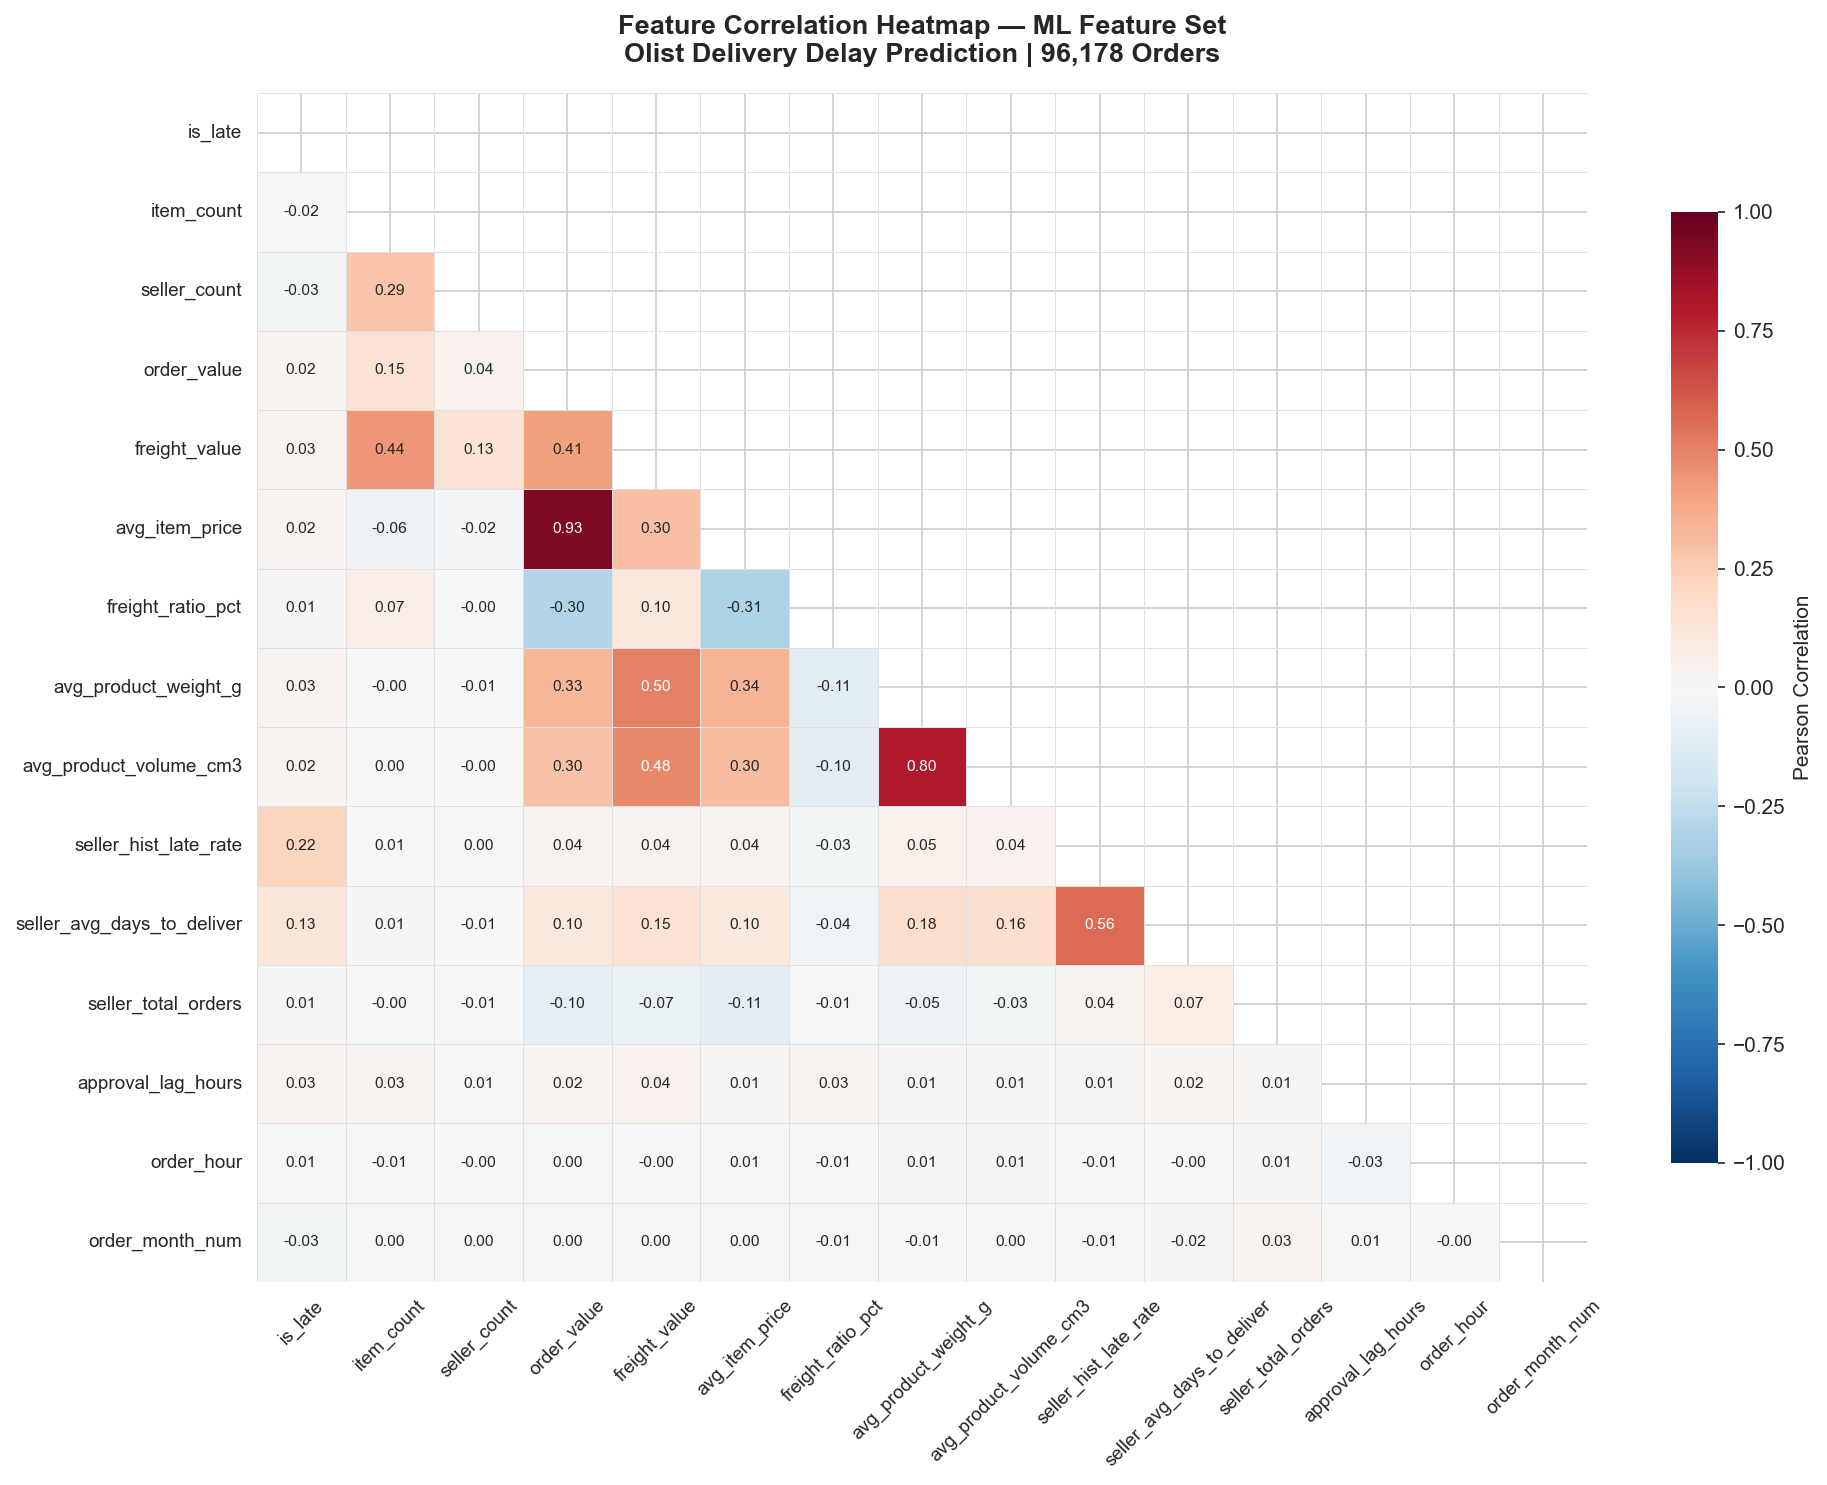

✅ Chart 9 saved.

--- High correlation pairs (|r| > 0.70, excluding target) ---
  order_value  ↔  avg_item_price  :  r = 0.933
  avg_product_weight_g  ↔  avg_product_volume_cm3  :  r = 0.805


In [31]:
# Chart 9: Feature correlation heatmap

corr_matrix = df_corr.corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7.5},
    linewidths=0.4,
    linecolor='#e0e0e0',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}
)

ax.set_title('Feature Correlation Heatmap — ML Feature Set\nOlist Delivery Delay Prediction | 96,178 Orders',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'chart09_feature_correlation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved.")

# Flag any high correlations between features (excluding is_late)
print("\n--- High correlation pairs (|r| > 0.70, excluding target) ---")
corr_features = df_corr.drop(columns='is_late').corr()
high_corr = []
cols = corr_features.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = corr_features.iloc[i, j]
        if abs(r) > 0.70:
            high_corr.append((cols[i], cols[j], round(r, 3)))

if high_corr:
    for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {pair[0]}  ↔  {pair[1]}  :  r = {pair[2]}")
else:
    print("  None found above 0.70 threshold.")

### Business Interpretation — Chart 9
**Multicollinearity check before modelling — two pairs flagged:**

**order_value ↔ avg_item_price (r = 0.933):** Near-identical signal. 
avg_item_price dropped from ML feature set — order_value retained as the 
more interpretable business variable.

**avg_product_weight_g ↔ avg_product_volume_cm3 (r = 0.805):** Moderate 
correlation — both retained. Weight and volume capture different physical 
dimensions of a product. Random Forest is robust to this level of correlation. 
Feature importance post-training will confirm if one is redundant.

**All other pairs below 0.70 — no further action needed.**

**ML feature set after this analysis:** 13 features 
(avg_item_price dropped from original 14 numeric features).

In [32]:
# ---- FULL EDA SANITY CHECK ----

print("=" * 60)
print("CHART 1 — RFM Segments")
print("=" * 60)
q = "SELECT COUNT(*) as customers, ROUND(SUM(monetary)::numeric,0) as revenue FROM olist.v_rfm_scores"
df = pd.read_sql(q, engine)
print(f"Total customers : {df['customers'][0]:,}  (expected: 93,470)")
print(f"Total revenue   : {df['revenue'][0]:,.0f} BRL  (expected: 15,422,462)")

print("\n" + "=" * 60)
print("CHART 2 — Cohort Retention")
print("=" * 60)
q = """SELECT COUNT(DISTINCT cohort_month) as cohorts,
       MAX(retention_rate_pct) as max_retention
       FROM olist.v_cohort_retention
       WHERE cohort_month != '2016-12-01'
       AND period_number > 0"""
df = pd.read_sql(q, engine)
print(f"Cohorts         : {df['cohorts'][0]}  (expected: 21)")
print(f"Max retention   : {df['max_retention'][0]:.4f}%  (expected: 0.7100)")

print("\n" + "=" * 60)
print("CHART 3 — Revenue Trend")
print("=" * 60)
q = """SELECT COUNT(DISTINCT order_month) as months,
       MAX(total_revenue) as peak,
       SUM(total_revenue) as total
       FROM (
           SELECT order_month, SUM(total_revenue) as total_revenue
           FROM olist.v_revenue_by_category
           GROUP BY order_month
       ) t"""
df = pd.read_sql(q, engine)
print(f"Months          : {df['months'][0]}  (expected: 23)")
print(f"Peak revenue    : {df['peak'][0]:,.0f} BRL  (expected: 1,137,527)")
print(f"Total revenue   : {df['total'][0]:,.0f} BRL  (expected: ~15,222,078)")

print("\n" + "=" * 60)
print("CHART 4 — Category SLA")
print("=" * 60)
q = """SELECT COUNT(*) as critical_categories
       FROM olist.v_category_sla
       WHERE sla_tier = 'Critical' AND total_orders >= 30"""
df = pd.read_sql(q, engine)
print(f"Critical cats   : {df['critical_categories'][0]}  (expected: 6)")
q2 = """SELECT product_category_name, late_rate_pct, p90_days_to_deliver
        FROM olist.v_category_sla ORDER BY late_rate_pct DESC LIMIT 1"""
df2 = pd.read_sql(q2, engine)
print(f"Worst category  : {df2['product_category_name'][0]}  late={df2['late_rate_pct'][0]:.2f}%  (expected: 13.51%)")
print(f"Worst p90       : {df2['p90_days_to_deliver'][0]} days")

print("\n" + "=" * 60)
print("CHART 5 — Revenue vs Late Rate Scatter")
print("=" * 60)
q = """SELECT COUNT(*) as categories FROM olist.v_category_sla WHERE total_orders >= 100"""
df = pd.read_sql(q, engine)
print(f"Categories      : {df['categories'][0]}  (expected: 51)")

print("\n" + "=" * 60)
print("CHART 6 — Seller Risk")
print("=" * 60)
q = """SELECT seller_risk_tier, COUNT(*) as sellers,
       ROUND(SUM(total_revenue)::numeric,0) as revenue,
       ROUND(AVG(late_rate_pct)::numeric,2) as avg_late_rate
       FROM olist.v_seller_performance
       WHERE total_orders >= 10
       GROUP BY seller_risk_tier ORDER BY avg_late_rate DESC"""
df = pd.read_sql(q, engine)
print(df.to_string(index=False))
print(f"Total sellers   : {df['sellers'].sum()}  (expected: 1,238)")

print("\n" + "=" * 60)
print("CHART 7 — Cancellation")
print("=" * 60)
q = """SELECT MAX(cancel_rate_pct) as max_monthly
       FROM olist.v_cancellation_analysis
       WHERE analysis_dimension = 'monthly'
       AND dimension_value != '2016-10-01'"""
df = pd.read_sql(q, engine)
print(f"Max monthly rate: {df['max_monthly'][0]:.2f}%  (expected: 3.48%)")
q2 = """SELECT dimension_value, cancel_rate_pct
        FROM olist.v_cancellation_analysis
        WHERE analysis_dimension = 'state'
        ORDER BY cancel_rate_pct DESC LIMIT 1"""
df2 = pd.read_sql(q2, engine)
print(f"Worst state     : {df2['dimension_value'][0]} at {df2['cancel_rate_pct'][0]:.2f}%  (expected: RO 2.77%)")

print("\n" + "=" * 60)
print("CHART 8 — Delay Drivers")
print("=" * 60)
q = """SELECT 
       ROUND(AVG(CASE WHEN is_late THEN seller_hist_late_rate END)::numeric,2) as late_seller_rate,
       ROUND(AVG(CASE WHEN NOT is_late THEN seller_hist_late_rate END)::numeric,2) as ontime_seller_rate,
       ROUND(AVG(CASE WHEN is_late THEN approval_lag_hours END)::numeric,2) as late_lag,
       ROUND(AVG(CASE WHEN NOT is_late THEN approval_lag_hours END)::numeric,2) as ontime_lag
       FROM olist.v_delivery_delay_drivers
       WHERE approval_lag_hours IS NOT NULL"""
df = pd.read_sql(q, engine)
print(f"Seller rate — late   : {df['late_seller_rate'][0]}%  (expected: ~11.62%)")
print(f"Seller rate — on time: {df['ontime_seller_rate'][0]}%  (expected: ~6.21%)")
print(f"Approval lag — late  : {df['late_lag'][0]} hrs  (expected: ~8.63)")
print(f"Approval lag — ontime: {df['ontime_lag'][0]} hrs  (expected: ~8.37)")

print("\n" + "=" * 60)
print("CHART 9 — Correlation")
print("=" * 60)
print(f"Rows in feature set : {len(df_corr):,}  (expected: 96,178)")
print(f"Nulls in feature set: {df_corr.isnull().sum().sum()}  (expected: 0)")
print(f"High corr pairs     : order_value↔avg_item_price (0.933), weight↔volume (0.805)")

print("\n" + "=" * 60)
print("ML FEATURE SET — Post Correlation Check")
print("=" * 60)
print("Dropped : avg_item_price (r=0.933 with order_value)")
print("Retained: 13 numeric features + customer_state + primary_category")
print("Target  : is_late")
print("Class split — late orders:")
q = """SELECT is_late, COUNT(*) as orders,
       ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER()::numeric,2) as pct
       FROM olist.v_delivery_delay_drivers
       GROUP BY is_late ORDER BY is_late"""
df = pd.read_sql(q, engine)
print(df.to_string(index=False))

CHART 1 — RFM Segments
Total customers : 93,470  (expected: 93,470)
Total revenue   : 15,422,462 BRL  (expected: 15,422,462)

CHART 2 — Cohort Retention
Cohorts         : 21  (expected: 21)
Max retention   : 0.7100%  (expected: 0.7100)

CHART 3 — Revenue Trend
Months          : 23  (expected: 23)
Peak revenue    : 1,137,527 BRL  (expected: 1,137,527)
Total revenue   : 15,222,078 BRL  (expected: ~15,222,078)

CHART 4 — Category SLA
Critical cats   : 6  (expected: 6)
Worst category  : moveis_colchao_e_estofado  late=13.51%  (expected: 13.51%)
Worst p90       : 28.6 days

CHART 5 — Revenue vs Late Rate Scatter
Categories      : 51  (expected: 51)

CHART 6 — Seller Risk
seller_risk_tier  sellers   revenue  avg_late_rate
       High Risk       12  182534.0          24.55
   Elevated Risk      186 3238896.0          15.07
         Average      806 5479842.0           6.14
Strong Performer      234 5132229.0           3.74
Total sellers   : 1238  (expected: 1,238)

CHART 7 — Cancellation
Max 

In [33]:
import glob
saved = sorted(glob.glob(os.path.join(SAVE_PATH, 'chart*.png')))
print(f"Charts saved: {len(saved)}")
for f in saved:
    print(f"  {os.path.basename(f)}")

Charts saved: 9
  chart01_rfm_segments.png
  chart02_cohort_retention.png
  chart03_revenue_trend.png
  chart04_category_sla.png
  chart05_category_revenue_vs_sla.png
  chart06_seller_risk.png
  chart07_cancellation_analysis.png
  chart08_delay_drivers.png
  chart09_feature_correlation.png
